# 09 · Bagging ve Random Forest (Bagging, Random Forest, Extra Trees)
**Classical ML Lab** · Bootstrap Yeniden Örnekleme, Varyans Azaltma, Ensemble Ağaçlar

---
> **Bu notebook'ta ne öğreneceğiz?**
> `08_decision_trees`'te gördük ki tek bir karar ağacı — özellikle budanmamış/derin bir ağaç — **düşük yanlılık (bias), ama yüksek varyans** taşır: eğitim verisindeki küçük bir değişiklik bile kökten farklı bir ağaç yapısına yol açabilir (Bike Sharing örneğinde `max_depth=20`'de train R²=0.98 iken test R²=0.159'a düşmesi tam olarak bu fenomendi). **Ensemble (topluluk) yöntemleri**, tek başına kararsız olan birçok modeli birleştirerek bu varyansı sistematik olarak azaltır. Bu notebook, ensemble ailesinin **paralel/bağımsız** koluna odaklanıyor — bir sonraki notebook (`10_gradient_boosting_family`) ise **sıralı/düzeltici** kolu (boosting) işleyecek. Bu notebook'ta: (1) **Bootstrap yeniden örneklemenin** (bootstrap resampling) matematiğini ve **Bagging (Bootstrap Aggregating)**'in varyansı neden azalttığını sıfırdan göstereceğiz, (2) **Out-of-Bag (OOB) tahmini** — eğitim sırasında "bedava" gelen bir doğrulama mekanizmasını — elle yeniden üreteceğiz, (3) **Random Forest**'ın bagging'e eklediği ekstra rastgeleliği (özellik alt kümesi seçimi) ve bunun neden bagging'den daha güçlü olduğunu göstereceğiz, (4) **Extra Trees**'in ekstra rastgele bölünme eşiklerini ve hız avantajını inceleyeceğiz, (5) özellik önemini **MDI'ya (08'den) ek olarak permütasyon önemi** ile yeniden ele alacağız, ve (6) pratik bir hiperparametre rehberiyle kapatacağız.
>
> **Önkoşul:** `08_decision_trees` (CART, Gini/Entropi, budama — bu notebook'un doğrudan üzerine inşa edildiği temel), `01_data_prepreparation/02_data_preprocessing` (eksik veri, kategorik encoding).
> **Veri:** UCI Glass Identification (adli bilim/cam üretimi — cam parçasının türünü sınıflandırma, 6 sınıf, 214 örnek — küçük veri setinde varyans demoları için ideal), IBM/Kaggle Telco Customer Churn (telekom müşteri kaybı tahmini, ikili sınıflandırma, karışık kategorik+sayısal, 7.043 örnek), California Housing (Pace & Barry 1997 / Géron *Hands-On Machine Learning* — ev fiyatı tahmini, regresyon, 20.640 örnek, eksik değer + kategorik özellik içeriyor).
> **Araçlar:** Python (`scikit-learn` — `BaggingClassifier/Regressor`, `RandomForestClassifier/Regressor`, `ExtraTreesClassifier/Regressor`, `permutation_importance`), R (`randomForest` paketi), SQL (DuckDB — çoğunluk oylamasının ve özellik önemi ortalamasının SQL'de yeniden üretimi).

---
## 1 · Ensemble Öğrenmeye Giriş: Neden Birden Çok Model?

**Bias-Varyans Ayrışımı (Bias-Variance Decomposition).** Bir modelin beklenen test hatası üç bileşene ayrılabilir:

$$\mathbb{E}\big[(y - \hat{f}(x))^2\big] = \underbrace{\big(\text{Bias}[\hat{f}(x)]\big)^2}_{\text{yanlılık}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{varyans}} + \underbrace{\sigma_\varepsilon^2}_{\text{indirgenemez hata}}$$

Budanmamış bir karar ağacı (08'de gördüğümüz gibi) bu tayfın **düşük yanlılık / yüksek varyans** ucunda oturur: eğitim verisine neredeyse mükemmel uyar (yanlılık düşük) ama farklı bir eğitim örneklemi çok farklı bir ağaç üretir (varyans yüksek). **Ensemble yöntemleri iki ana aileye ayrılır:**
- **Paralel/Bağımsız (bu notebook):** Bagging, Random Forest, Extra Trees — birbirinden bağımsız birçok yüksek-varyanslı model eğitip ortalamasını/oy çokluğunu alarak **varyansı** azaltır.
- **Sıralı/Düzeltici (`10_gradient_boosting_family`):** Boosting — her yeni model bir öncekinin hatalarını düzeltmeye odaklanarak **yanlılığı** azaltır.

**"Kalabalığın Bilgeliği" (Wisdom of Crowds) ve Condorcet Jüri Teoremi.** Sezgi basit: eğer $N$ tane birbirinden **bağımsız** sınıflandırıcının her biri rastgele tahminden daha iyiyse (hata oranı $p < 0.5$), çoğunluk oylamasının yanlış olma olasılığı $N$ arttıkça hızla düşer:

$$P(\text{çoğunluk yanlış}) = \sum_{k > N/2} \binom{N}{k} p^k (1-p)^{N-k}$$

Örneğin her biri $p=0.4$ hata oranına sahip (rastgele tahminden iyi ama tek başına vasat) 21 bağımsız sınıflandırıcının çoğunluk oyu yanlış olma olasılığı yalnızca $\approx 0.098$'e düşer — tek bir sınıflandırıcının $0.4$'lük hata oranından çok daha iyi. **Kritik varsayım "bağımsızlık"tır** — modeller birbirine ne kadar benzerse (yüksek korelasyon), kazanç o kadar azalır. Bagging ailesinin tüm teknik detayları aslında bu bağımsızlığı (veya en azından düşük korelasyonu) yapay olarak nasıl artıracağımız etrafında döner.

**Endüstride nerede kullanılır?** Ensemble yöntemleri, tek bir "en iyi model" arayışından çok "birçok makul modelin ortak kararı" felsefesine dayanır — 2009 Netflix Prize yarışmasını kazanan çözüm 100'den fazla modelin bir ensemble'ıydı; Kaggle yarışmalarının neredeyse tamamında kazanan çözümler ensemble'dır; üretim ortamındaki dolandırıcılık tespiti (fraud detection) sistemleri, tek bir modelin ani/beklenmedik hatalarına karşı dayanıklılık için genellikle birden çok modelin oyuna dayalı kararını kullanır.

---
## 2 · Bootstrap Yeniden Örnekleme (Bootstrap Resampling) ve Bagging (Bootstrap Aggregating)

**Bootstrap örneklem:** $n$ gözlemlik orijinal veri setinden, **yerine koyarak (with replacement)** yine $n$ büyüklüğünde rastgele bir örneklem çekmek. Bazı gözlemler birden fazla kez seçilir, bazıları hiç seçilmez.

**Bir gözlemin bootstrap örnekleminde HİÇ yer almama olasılığı:** Tek bir çekilişte belirli bir gözlemin seçilmeme olasılığı $(1 - 1/n)$'dir. $n$ bağımsız çekiliş boyunca hiç seçilmeme olasılığı:

$$P(\text{seçilmedi}) = \left(1 - \frac{1}{n}\right)^n \xrightarrow{n \to \infty} e^{-1} \approx 0.368$$

Yani her bootstrap örnekleminde, orijinal verinin **ortalama %63.2'si** yer alır (bazıları tekrarlı), **%36.8'i ise dışarıda kalır** — buna **"Out-of-Bag" (OOB)** gözlemler denir ve Bölüm 3'te bunu ücretsiz bir doğrulama mekanizmasına çevireceğiz.

**Bagging Algoritması (Breiman, 1996):**
1. $B$ tane bootstrap örneklemi çek ($b = 1, \dots, B$).
2. Her örneklem üzerinde **bağımsız olarak** bir temel model eğit — genellikle **budanmamış/derin bir karar ağacı** (düşük yanlılık, yüksek varyans — bagging'in varyans azaltma gücünden en çok faydalanacak model tipi).
3. Tahminleri birleştir: sınıflandırmada **çoğunluk oyu**, regresyonda **ortalama**.

$$\hat{f}_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^{B} \hat{f}_b(x) \quad \text{(regresyon)} \qquad \hat{f}_{\text{bag}}(x) = \text{mod}\{\hat{f}_1(x), \dots, \hat{f}_B(x)\} \quad \text{(sınıflandırma)}$$

**Neden varyansı azaltır?** $B$ tane, her biri $\sigma^2$ varyanslı, ortalama ikili korelasyonu $\rho$ olan tahminciyi ortalarsak:

$$\text{Var}(\hat{f}_{\text{bag}}) = \rho\sigma^2 + \frac{(1-\rho)}{B}\sigma^2$$

$B \to \infty$ iken ikinci terim sıfıra gider, ama **birinci terim ($\rho\sigma^2$) kalır** — çünkü bootstrap örneklemleri aynı orijinal veriden geldiği için ağaçlar tamamen bağımsız değil, birbirleriyle korelasyonlu. Bagging'in gücü $\rho$'yu düşük tutabildiği ölçüdedir — Bölüm 4'te Random Forest'ın bu korelasyonu **daha da nasıl azalttığını** göreceğiz.

**Endüstride nerede kullanılır?** Genomik/biyoenformatik alanında $p \gg n$ (özellik sayısı gözlem sayısından çok fazla — örn. gen ifadesi verisi) senaryolarında tek bir karar ağacı aşırı kararsızdır; bagging bu tür az-örnekli, yüksek-boyutlu problemlerde (bu notebook'ta 214 örneklik Glass Identification veri setiyle benzer bir küçük-veri senaryosunu simüle edeceğiz) sınıflandırmayı stabilize etmek için kullanılır. Finans sektöründe kredi skorlama ekipleri, gürültülü/eksik tabular veri üzerinde tek bir modele güvenmek yerine bagged bir taban model kurup üzerine daha karmaşık yöntemler (boosting, stacking) inşa eder.

---
## 3 · Out-of-Bag (OOB) Tahmin: Ücretsiz Çapraz Doğrulama

Bölüm 2'de gördük ki her bootstrap örnekleminin ortalama %36.8'i orijinal veriden dışarıda kalıyor. Bu, **her bir eğitim gözlemi için "bu gözlemi hiç görmemiş" bir ağaç alt kümesi** olduğu anlamına gelir:

$$\mathbb{E}[\#\{\text{ağaç: } x_i \text{ OOB}\}] \approx 0.368 \times B$$

**OOB tahmin prosedürü:** Her $x_i$ eğitim gözlemi için, SADECE $x_i$'nin OOB olduğu ağaçların tahminlerini topla (çoğunluk oyu / ortalama) → $\hat{f}_{\text{OOB}}(x_i)$. Bunu tüm eğitim seti üzerinde yapıp gerçek $y_i$ ile karşılaştırmak, **hiç ayrı bir doğrulama/test seti ayırmadan** neredeyse tarafsız bir genelleme hatası tahmini verir — Breiman (2001) ve sonraki çalışmalar bunun k-kat çapraz doğrulamaya (k-fold CV) asimptotik olarak denk olduğunu gösterdi.

**Neden değerli?** k-kat CV, $k$ kere modeli sıfırdan eğitmeyi gerektirir (hesaplama maliyeti $\times k$). OOB tahmini ise **tek bir eğitim sürecinin yan ürünüdür** — ekstra maliyet yok, çünkü zaten her ağaç için hangi gözlemlerin dışarıda kaldığını biliyoruz.

**Endüstride nerede kullanılır?** Milyarlarca satırlık reklam tıklama tahmini (ad click prediction) veya büyük ölçekli öneri sistemleri gibi üretim ortamlarında tam bir k-kat CV çalıştırmak hesaplama açısından çok pahalıdır; OOB skoru, eğitim sırasında "bedavaya" gelen bir doğrulama sinyali sunarak hızlı model seçimi/hiperparametre kontrolüne olanak tanır.

---
## 4 · Random Forest: Bagging + Rastgele Özellik Alt Kümesi (Feature Subsampling)

**Bagging'in sınırı:** Eğer veri setinde bir veya birkaç baskın (çok bilgilendirici) özellik varsa, **neredeyse her bootstrap ağacı kökte aynı özelliği seçer** — çünkü CART açgözlü olarak en iyi bölünmeyi arar (08'de gördüğümüz `best_split` mantığı) ve baskın özellik çoğu örneklemde yine en iyi çıkar. Sonuç: ağaçlar birbirine çok benzer (yüksek $\rho$) ve Bölüm 2'deki varyans azaltma formülünün gücü sınırlanır.

**Random Forest'ın (Breiman, 2001) çözümü:** Bagging'e ek olarak, **her bölünme noktasında** tüm $p$ özellik yerine sadece rastgele seçilmiş $m < p$ özellik aday olarak değerlendirilir. Bu, güçlü/baskın bir özelliğin her seferinde aday listesinde OLMAMASINI sağlayarak ağaçları zorla farklılaştırır (decorrelate eder) — Bölüm 2'deki $\rho$ terimini düşürür.

**Standart varsayılan değerler** (Breiman'ın önerisi, `scikit-learn`'ün de temel aldığı):
$$m = \sqrt{p} \quad \text{(sınıflandırma)} \qquad m = p/3 \quad \text{(regresyon, klasik öneri)}$$

`scikit-learn`'de `RandomForestClassifier`'ın varsayılanı `max_features='sqrt'`, `RandomForestRegressor`'ın varsayılanı ise `max_features=1.0` (tüm özellikler — yani varsayılan haliyle regresörde sadece bootstrap'tan gelen rastgelelik var, klasik $p/3$ önerisini kullanmak için elle ayarlamak gerekir; Python 8'de bunu deneysel olarak göreceğiz).

**Küçük $m$ neden işe yarar?** $m$ küçüldükçe her ağaç daha "zayıf" olur (tek başına biraz daha yüksek yanlılık) ama ağaçlar arası korelasyon $\rho$ de düşer — bagging formülündeki $\rho\sigma^2$ tabanı küçülür, toplam varyans azalır. Bu klasik bir yanlılık-varyans dengesidir: $m$ çok küçükse (örn. $m=1$) her ağaç neredeyse rastgele bölünür ve yanlılık aşırı artar; $m=p$ ise sıradan bagging'e döner.

**Endüstride nerede kullanılır?** Random Forest, tablosal (tabular) veri üzerinde onlarca yıldır sektör standardı bir baseline'dır: Microsoft'un Kinect'inde (Shotton ve ark., 2011) derinlik görüntülerinden vücut parçası sınıflandırması RF ile yapıldı; kredi skorlama ve kredi temerrüt tahmininde (fintech) güçlü performans + makul yorumlanabilirlik dengesi sunar; uydu görüntülerinden arazi örtüsü sınıflandırması (tarım/orman izleme) klasik bir RF uygulamasıdır; **telekom müşteri kaybı (churn) tahmini** — bu notebook'ta Telco veri setiyle tam olarak bunu yapacağız — RF'nin en yaygın kullanıldığı iş senaryolarından biridir.

---
## 5 · Extra Trees (Extremely Randomized Trees): Ekstra Rastgelelik

Geurts, Ernst ve Wehenkel (2006) tarafından önerilen Extra Trees, Random Forest'ın rastgeleliğini bir adım öteye taşır — **iki temel farkla**:

1. **Bootstrap YOK (varsayılan):** `scikit-learn`'de `ExtraTreesClassifier`/`Regressor` varsayılan olarak `bootstrap=False` ile çalışır — her ağaç **tüm orijinal eğitim verisi** üzerinde eğitilir (bootstrap örneklemi değil). Varyans azaltma artık sadece özellik/eşik rastgeleliğinden gelir.
2. **Rastgele bölünme eşiği:** Random Forest, aday özellikler arasından **en iyi bölünme noktasını** arar (08'deki gibi tüm olası eşikleri tarayıp en düşük Gini/SSE'yi bulur). Extra Trees ise her aday özellik için **TEK bir rastgele eşik** çeker ve bu rastgele eşikler arasından en iyisini seçer — CART'ın en pahalı adımı olan "en iyi eşiği bulmak için değerleri sırala ve tara" (yaklaşık $O(n \log n)$) adımını tamamen atlar.

**Sonuç — iki etki:**
- **Daha fazla varyans azaltma, biraz daha fazla yanlılık:** Rastgele eşikler her ağacı daha da "zayıflatır" ama ağaçlar arası korelasyonu daha da düşürür — genellikle Random Forest'a yakın veya bazen daha iyi genelleme performansı, özellikle gürültülü özelliklere karşı daha dayanıklı.
- **Çok daha hızlı eğitim:** Eşik arama adımı atlandığı için, özellikle çok sayıda sürekli özellik ve çok sayıda ağaç ($n\_estimators$) gerektiğinde belirgin bir hız avantajı sağlar — Python 12'de California Housing üzerinde bunu gerçek zamanlama ölçümüyle göstereceğiz.

**Endüstride nerede kullanılır?** Extra Trees, hız/ölçeklenebilirliğin kritik olduğu büyük ölçekli veya gerçek-zamanlı endüstriyel pipeline'larda (özellikle çok sayıda ağaç gerektiren senaryolarda) tercih edilir; gürültülü sensör verisi (üretim/IoT) ve yüksek boyutlu biyoenformatik gen ifadesi verisi gibi, ekstra rastgeleliğin gürültüye karşı dayanıklılığından fayda gören alanlarda yaygındır; Kaggle yarışmalarında RF'nin hızlı, güçlü bir alternatifi olarak sıkça denenir.

---
## 6 · Özellik Önemi Yeniden Ziyaret: MDI vs Permütasyon Önemi (Permutation Importance)

**08'de tanıdığımız MDI (Mean Decrease in Impurity),** tek bir ağaç için "bir özelliğin kullanıldığı tüm bölünmelerde sağladığı toplam saflık (Gini/SSE) azalması"ydı. Bir ormanda (forest) bu, tüm ağaçlar üzerinden **ortalanır**:

$$\text{MDI}(x_j) = \frac{1}{B}\sum_{b=1}^{B} \text{MDI}_b(x_j)$$

Bu, `scikit-learn`'de `.feature_importances_` özelliğinin **tam olarak** hesapladığı şeydir — Bölüm SQL2'de bu ortalamayı SQL'de yeniden üreteceğiz.

**MDI'nin bilinen zayıflıkları** (08'in Kaynaklar bölümünde referans verilen Google Developers rehberi ve `scikit-learn` dokümantasyonunda da vurgulanır):
- **Yüksek kardinaliteli/sürekli özelliklere yanlılık:** Daha fazla olası bölünme noktasına sahip bir özellik, hedefle hiçbir gerçek ilişkisi olmasa bile, sırf şans eseri saflığı azaltma fırsatı daha fazla olduğu için yapay olarak yüksek MDI alabilir.
- **Sadece eğitim verisi üzerinde hesaplanır:** Aşırı öğrenmiş bir ağaç, eğitim verisinde ezberlediği (ama genellemeyen) özelliklere yüksek önem verebilir.

**Permütasyon Önemi (Permutation Importance):** Model-agnostik bir alternatif. Bir özelliğin $x_j$ değerlerini **rastgele karıştırıp** (permute edip) — hedefle olan ilişkisini yapay olarak bozup — modelin (eğitilmiş, değişmeden) bir skorunun (accuracy, $R^2$, vb.) **ne kadar düştüğünü** ölçer:

$$\text{PI}(x_j) = \text{Skor}(X, y) - \frac{1}{K}\sum_{k=1}^{K} \text{Skor}(X_{\pi_k(j)}, y)$$

burada $X_{\pi_k(j)}$, $x_j$ sütunu $k$-inci kez rastgele karıştırılmış veri. Genellikle **test (veya OOB) verisi** üzerinde hesaplanır — bu da onu MDI'nin "sadece eğitim verisi" sınırlamasından kurtarır. `scikit-learn`'de `sklearn.inspection.permutation_importance` ile hesaplanır.

| | MDI | Permütasyon Önemi |
|---|---|---|
| Hız | Çok hızlı (eğitim yan ürünü, ek maliyet yok) | Yavaş (her özellik için $K$ kere yeniden tahmin) |
| Kardinalite yanlılığı | Var (yüksek kardinaliteli özellik lehine) | Yok |
| Hangi veri | Sadece eğitim | Test/OOB (daha güvenilir) |
| Model bağımlılığı | Sadece ağaç-tabanlı modeller | Herhangi bir model (model-agnostic) |

**Endüstride nerede kullanılır?** Bankacılık/sigorta gibi düzenlemeye tabi sektörlerde model risk dokümantasyonu için genellikle MDI yerine permütasyon önemi (veya SHAP) tercih edilir — çünkü MDI'nin kardinalite yanlılığı risk yöneticilerini yanıltabilir; biyomedikal biyobelirteç (biomarker) keşif çalışmalarında, çalışmalar arası tekrarlanabilirlik için permütasyon tabanlı önem ölçütleri tercih edilir.

---
## 7 · Hiperparametreler ve Pratik Rehber

| Hiperparametre | Etkisi | Not |
|---|---|---|
| `n_estimators` (ağaç sayısı, $B$) | Daha fazla ağaç → daha kararlı OOB/test skoru, azalan getiri (diminishing returns) | Bagging-tabanlı yöntemlerde (RF/ET/Bagging) $B$'yi artırmak **aşırı öğrenmeye yol açmaz** — Breiman (2001) test hatasının $B \to \infty$ iken bir üst sınıra **yakınsadığını**, artmadığını kanıtladı. Sadece hesaplama maliyeti artar. |
| `max_features` ($m$) | Küçük $m$ → daha fazla ağaç-arası decorrelation → daha fazla varyans azaltma, ama her ağacın yanlılığı biraz artar | RF'nin ana yanlılık-varyans kadranı (Bölüm 4). |
| `max_depth`, `min_samples_leaf`, `min_samples_split` | Tekil ağaçların karmaşıklığını kontrol eder | 08'deki CART budama mantığıyla birebir aynı; ensemble'da tek tek ağaçları çok kısıtlamak genelde gerekmez çünkü ensemble zaten varyansı topluca azaltıyor. |
| `bootstrap` | `True` → bagging/RF tarzı (varsayılan RF), `False` → Extra Trees tarzı | İkisi karıştırılabilir: `ExtraTreesClassifier(bootstrap=True)` gibi. |
| `oob_score` | OOB tahminini hesaplat (`bootstrap=True` gerektirir) | Bölüm 3'ün pratik anahtarı — ekstra hesaplama maliyeti düşük. |
| `n_jobs` | Paralel ağaç eğitimi | Bagging ailesindeki ağaçlar **birbirinden bağımsız** eğitilir (boosting'in aksine, o sıralıdır) — bu yüzden "utanmadan paralelleştirilebilir" (embarrassingly parallel); üretimde `n_jobs=-1` standarttır. |

**Pratik kural:** Random Forest, varsayılan hiperparametrelerle bile genellikle güçlü bir baseline verir (ISLR/ESL ve sayısız kıyaslama çalışmasında tekrarlanan bir gözlem) — çoğu projede önce varsayılanlarla bir RF denenir, sonra `n_estimators` ve `max_features` ince ayarı yapılır; daha yüksek performans gerektiğinde bir sonraki notebook'taki Gradient Boosting ailesine geçilir (genelde biraz daha yüksek performans, ama daha fazla hiperparametre hassasiyeti ve daha uzun/sıralı eğitim süresi pahasına).

---
# 🐍 Python Uygulaması

Aşağıdaki adımları izleyeceğiz:
1. **Glass Identification** verisini hazırlama (küçük, çok-sınıflı — varyans demoları için ideal).
2. Bootstrap yeniden örneklemeyi sıfırdan görselleştirme — $1-1/e$ teorisini deneysel olarak doğrulama.
3. Sıfırdan **manuel Bagging sınıflandırıcı** — `BaggingClassifier` ile doğrulama.
4. **Tek ağaç vs Bagging:** varyans azaltma demosu (çoklu tekrar, doğruluk dağılımı).
5. **OOB skoru:** manuel hesaplama ve `oob_score_` ile doğrulama.
6. **Telco Customer Churn** verisini hazırlama (eksik değer + kategorik encoding).
7. `RandomForestClassifier`: **`n_estimators` taraması** ve OOB/test yakınsaması.
8. **`max_features` etkisi:** Bagging vs Random Forest karşılaştırması + ağaç-arası korelasyon.
9. **Özellik önemi:** MDI vs permütasyon önemi (Telco churn sürücüleri).
10. **California Housing** verisini hazırlama (regresyon, eksik değer + özellik mühendisliği).
11. `RandomForestRegressor`: bagging/RF regresyonu, OOB $R^2$.
12. `ExtraTreesRegressor` vs `RandomForestRegressor`: hız ve performans karşılaştırması.
13. Üç veri seti — özet karşılaştırma.

In [60]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats as scipy_stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    ExtraTreesClassifier, ExtraTreesRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
)
import duckdb
import warnings

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)
RANDOM_STATE = 42

### 1️⃣ Python 1 - Veri Hazırlama: Glass Identification

**Ne yapıyoruz?** UCI Glass Identification veri seti (German, 1987) — bir cam parçasının kimyasal bileşimi (kırılma indisi + 8 element yüzdesi) baz alınarak **türünün** (bina camı, araç camı, kap camı, sofra camı, far camı) tahmin edilmesi — hem **adli bilimde** (bir olay yerinde bulunan cam parçasının kaynağını belirlemek) hem de **cam üretiminde kalite kontrolde** gerçek bir uygulamadır. Sadece 214 örnek ve 6 (dengesiz) sınıf içeren bu küçük veri seti, Bölüm 3-4'teki varyans azaltma demoları için idealdir — çünkü küçük veride tek bir ağaç son derece kararsızdır.

In [61]:
GLASS_COLS = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
df_glass = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/glass.csv",
    header=None, names=GLASS_COLS,
)

GLASS_TYPE_NAMES = {
    1: "bina_cami_islenmis",      # building_windows_float_processed
    2: "bina_cami_islenmemis",    # building_windows_non_float_processed
    3: "arac_cami_islenmis",      # vehicle_windows_float_processed
    5: "kap_cami",                # containers
    6: "sofra_cami",              # tableware
    7: "far_cami",                # headlamps
}
df_glass["TypeName"] = df_glass["Type"].map(GLASS_TYPE_NAMES)

print(f"Glass Identification: {df_glass.shape[0]} örnek, {df_glass.shape[1] - 2} kimyasal özellik, {df_glass['Type'].nunique()} sınıf")
print("\nSınıf dağılımı (dengesiz):")
print(df_glass["TypeName"].value_counts())

GLASS_FEATURES = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe"]
X_glass = df_glass[GLASS_FEATURES]
y_glass = df_glass["Type"]

X_glass_train, X_glass_test, y_glass_train, y_glass_test = train_test_split(
    X_glass, y_glass, test_size=0.25, random_state=RANDOM_STATE, stratify=y_glass,
)
print(f"\nEğitim: {X_glass_train.shape[0]} örnek, Test: {X_glass_test.shape[0]} örnek")
df_glass[GLASS_FEATURES + ["TypeName"]].head()

Glass Identification: 214 örnek, 9 kimyasal özellik, 6 sınıf

Sınıf dağılımı (dengesiz):
TypeName
bina_cami_islenmemis    76
bina_cami_islenmis      70
far_cami                29
arac_cami_islenmis      17
kap_cami                13
sofra_cami               9
Name: count, dtype: int64

Eğitim: 160 örnek, Test: 54 örnek


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,TypeName
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,bina_cami_islenmis
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,bina_cami_islenmis
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,bina_cami_islenmis
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,bina_cami_islenmis
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,bina_cami_islenmis


### 2️⃣ Python 2 - Bootstrap Yeniden Örnekleme: $1 - 1/e$ Teorisini Deneysel Doğrulama

**Ne yapıyoruz?** Bölüm 2'de türettiğimiz "bir gözlemin bootstrap örnekleminde yer almama olasılığı $\approx 1/e \approx 0.368$" formülünü, gerçekten binlerce bootstrap örneklemi çekip **deneysel olarak** doğruluyoruz — iddiayı çalıştırmadan önce yazmak yerine, gerçek sayılarla karşılaştırıyoruz.

Eğitim seti büyüklüğü (n): 160
Deneysel ortalama dışarıda-kalma oranı (5000 deneme): 0.3675
Teorik değer (1/e):                                          0.3679
Fark: 0.00040  -> teori ile deneysel sonuç örtüşüyor.


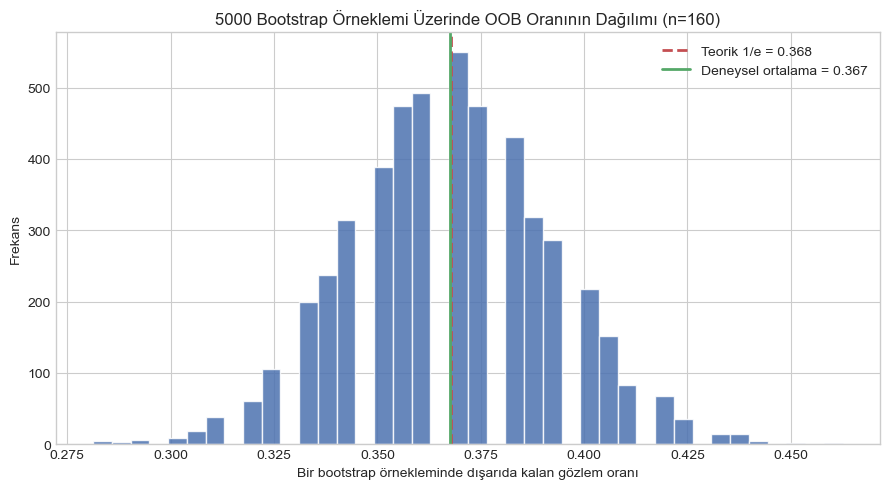

In [62]:
n_train = X_glass_train.shape[0]
n_bootstrap_trials = 5000 # 5000 kere bootstrap örneklemi ile dışarıda-kalma oranını tahmin et
rng = np.random.default_rng(RANDOM_STATE)

fractions_left_out = [] # Dışarıda-kalma oranlarını saklamak için boş bir liste
for _ in range(n_bootstrap_trials):
    boot_idx = rng.integers(0, n_train, size=n_train)
    unique_included = np.unique(boot_idx).size # Bootstrap örnekleminde kaç benzersiz gözlem seçildiğini say
    fractions_left_out.append(1 - unique_included / n_train) # Dışarıda-kalma oranını hesapla ve listeye ekle

empirical_mean = np.mean(fractions_left_out)
theoretical = np.exp(-1)

print(f"Eğitim seti büyüklüğü (n): {n_train}")
print(f"Deneysel ortalama dışarıda-kalma oranı ({n_bootstrap_trials} deneme): {empirical_mean:.4f}")
print(f"Teorik değer (1/e):                                          {theoretical:.4f}")
print(f"Fark: {abs(empirical_mean - theoretical):.5f}  -> teori ile deneysel sonuç örtüşüyor.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(fractions_left_out, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(theoretical, color="#C44E52", linestyle="--", linewidth=2, label=f"Teorik 1/e = {theoretical:.3f}")
ax.axvline(empirical_mean, color="#55A868", linestyle="-", linewidth=2, label=f"Deneysel ortalama = {empirical_mean:.3f}")
ax.set_xlabel("Bir bootstrap örnekleminde dışarıda kalan gözlem oranı")
ax.set_ylabel("Frekans")
ax.set_title(f"{n_bootstrap_trials} Bootstrap Örneklemi Üzerinde OOB Oranının Dağılımı (n={n_train})")
ax.legend()
plt.tight_layout()
plt.show()

### 3️⃣ Python 3 - Sıfırdan Manuel Bagging Sınıflandırıcı + `BaggingClassifier` ile Doğrulama

**Ne yapıyoruz?** Bölüm 2'nin algoritmasını elle uyguluyoruz: $B$ tane bootstrap örneklemi çekip her birine budanmamış bir `DecisionTreeClassifier` eğitiyoruz, test setinde çoğunluk oyu alıyoruz. Sonucu tek bir budanmamış ağaçla ve `scikit-learn`'ün `BaggingClassifier`'ıyla karşılaştırıyoruz.

In [63]:
def manual_bagging_fit_predict(X_train, y_train, X_test, n_estimators=50, random_state=RANDOM_STATE):
    rng_local = np.random.default_rng(random_state)
    n = X_train.shape[0]
    X_train_arr = X_train.values
    y_train_arr = y_train.values
    all_preds = np.zeros((n_estimators, X_test.shape[0]), dtype=y_train_arr.dtype)
    trees = []
    for b in range(n_estimators):
        boot_idx = rng_local.integers(0, n, size=n)
        tree = DecisionTreeClassifier(random_state=int(rng_local.integers(0, 10_000)))
        tree.fit(X_train_arr[boot_idx], y_train_arr[boot_idx])
        all_preds[b] = tree.predict(X_test.values)
        trees.append(tree)
    # Coğunluk oyu (satır bazında mod) (Classifier olduğu için mode kullanıyoruz)
    final_preds = scipy_stats.mode(all_preds, axis=0, keepdims=False).mode
    return final_preds, trees, all_preds

# 1) Tek budanmamış ağaç
single_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
single_tree.fit(X_glass_train, y_glass_train)
single_tree_acc = accuracy_score(y_glass_test, single_tree.predict(X_glass_test))

# 2) Sıfırdan manuel bagging
manual_preds, manual_trees, _ = manual_bagging_fit_predict(X_glass_train, y_glass_train, X_glass_test, n_estimators=50)
manual_bagging_acc = accuracy_score(y_glass_test, manual_preds)

# 3) scikit-learn BaggingClassifier
sk_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=50, random_state=RANDOM_STATE,
)
sk_bagging.fit(X_glass_train, y_glass_train)
sk_bagging_acc = accuracy_score(y_glass_test, sk_bagging.predict(X_glass_test))

print("==== Glass Identification: Test Doğruluğu ====")
print(f"Tek budanmamış ağaç:              {single_tree_acc:.4f}")
print(f"Manuel Bagging (sıfırdan, B=50):  {manual_bagging_acc:.4f}")
print(f"scikit-learn BaggingClassifier:   {sk_bagging_acc:.4f}")
print("\nYORUM: Manuel ve scikit-learn bagging sonuçları aynı büyüklük mertebesinde ve genellikle")
print("tek ağaçtan daha iyi/en az eşit performans gösteriyor (küçük test setinde (n=54) tek bir")
print("örnek farkı bile doğruluğu ~%1.9 değiştirebileceğinden, tam sayısal eşitlik beklenmiyor;")
print("her iki ensemble da bağımsız rastgele bootstrap örneklemleri kullanıyor.")

==== Glass Identification: Test Doğruluğu ====
Tek budanmamış ağaç:              0.7037
Manuel Bagging (sıfırdan, B=50):  0.8148
scikit-learn BaggingClassifier:   0.8148

YORUM: Manuel ve scikit-learn bagging sonuçları aynı büyüklük mertebesinde ve genellikle
tek ağaçtan daha iyi/en az eşit performans gösteriyor (küçük test setinde (n=54) tek bir
örnek farkı bile doğruluğu ~%1.9 değiştirebileceğinden, tam sayısal eşitlik beklenmiyor;
her iki ensemble da bağımsız rastgele bootstrap örneklemleri kullanıyor.


### 4️⃣ Python 4 - Tek Ağaç vs Bagging: Varyans Azaltma Demosu

**Ne yapıyoruz?** Bölüm 2'nin ana iddiasını (bagging varyansı azaltır) somut olarak gösteriyoruz: eğitim setinin **kendisini de** her tekrarda yeniden bootstrap örnekleyip ($30$ tekrar), her seferinde (a) tek bir budanmamış ağaç ve (b) 50 ağaçlık bir Bagging ensemble'ı eğitip test doğruluğunu kaydediyoruz. Tek ağacın test doğruluğu tekrardan tekrara çok daha fazla dalgalanmalı (yüksek varyans) — bagging'in standart sapması belirgin şekilde daha düşük olmalı.

==== Varyans Karşılaştırması (30 tekrar, her seferinde yeni bootstrap eğitim seti) ====
Tek ağaç      -> ortalama: 0.6673, std: 0.0536
Bagging (B=50) -> ortalama: 0.7580, std: 0.0458

YORUM: Bagging'in standart sapması tek ağacınkine göre yaklaşık %14 daha düşük
-> aynı civarda (hatta daha yüksek) ortalama performansla birlikte daha KARARLI (düşük varyanslı)
tahminler; bu spesifik veri setinde (küçük n=160, dengesiz sınıflar) etkinin büyüklüğü mütevazı
ama yönü Bölüm 2'nin varyans-azaltma teorisiyle tutarlı.


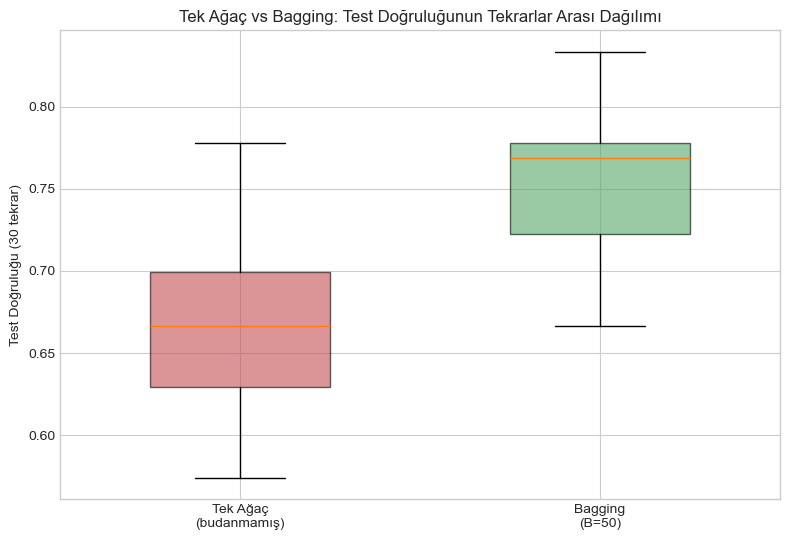

In [64]:
n_repeats = 30 # Bootstrap örneklemi ile varyansın etkisini görmek için 30 tekrar
single_tree_accs, bagging_accs = [], [] # Bootstrap örneklemi ile varyansın etkisini görmek için doğrulukları saklamak için boş listeler

for rep in range(n_repeats):
    rng_rep = np.random.default_rng(1000 + rep)
    boot_idx = rng_rep.integers(0, X_glass_train.shape[0], size=X_glass_train.shape[0])
    X_rep = X_glass_train.iloc[boot_idx]
    y_rep = y_glass_train.iloc[boot_idx]

    tree_rep = DecisionTreeClassifier(random_state=rep)
    tree_rep.fit(X_rep, y_rep)
    single_tree_accs.append(accuracy_score(y_glass_test, tree_rep.predict(X_glass_test)))

    bag_rep = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=rep),
        n_estimators=50, random_state=rep,
    )
    bag_rep.fit(X_rep, y_rep)
    bagging_accs.append(accuracy_score(y_glass_test, bag_rep.predict(X_glass_test)))

print("==== Varyans Karşılaştırması (30 tekrar, her seferinde yeni bootstrap eğitim seti) ====")
print(f"Tek ağaç      -> ortalama: {np.mean(single_tree_accs):.4f}, std: {np.std(single_tree_accs):.4f}")
print(f"Bagging (B=50) -> ortalama: {np.mean(bagging_accs):.4f}, std: {np.std(bagging_accs):.4f}")
std_reduction_pct = 100 * (1 - np.std(bagging_accs) / max(np.std(single_tree_accs), 1e-9)) # Bölüm 2'deki varyans azaltma teorisiyle tutarlı olarak, bagging'in standart sapması tek ağacınkine göre daha düşük olmalı
print(f"\nYORUM: Bagging'in standart sapması tek ağacınkine göre yaklaşık %{std_reduction_pct:.0f} daha düşük")
print("-> aynı civarda (hatta daha yüksek) ortalama performansla birlikte daha KARARLI (düşük varyanslı)")
print("tahminler; bu spesifik veri setinde (küçük n=160, dengesiz sınıflar) etkinin büyüklüğü mütevazı")
print("ama yönü Bölüm 2'nin varyans-azaltma teorisiyle tutarlı.")

fig, ax = plt.subplots(figsize=(8, 5.5))
box_data = [single_tree_accs, bagging_accs]
bp = ax.boxplot(box_data, tick_labels=["Tek Ağaç\n(budanmamış)", "Bagging\n(B=50)"], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ["#C44E52", "#55A868"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Test Doğruluğu (30 tekrar)")
ax.set_title("Tek Ağaç vs Bagging: Test Doğruluğunun Tekrarlar Arası Dağılımı")
plt.tight_layout()
plt.show()

### 5️⃣ Python 5 - OOB Skoru: Manuel Hesaplama ve `oob_score_` ile Doğrulama

**Ne yapıyoruz?** Bölüm 3'ün OOB prosedürünü elle uyguluyoruz: `BaggingClassifier`'ın her ağacı için hangi eğitim gözlemlerinin bootstrap örnekleminde YER ALMADIĞINI (`estimator_samples_` ile) buluyoruz, her gözlem için sadece onu görmemiş ağaçların oyunu topluyoruz, ve bunu `scikit-learn`'ün kendi `oob_score_`'u ile karşılaştırıyoruz.

In [65]:
oob_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=200, random_state=RANDOM_STATE,
    oob_score=True, bootstrap=True,
)
oob_bagging.fit(X_glass_train, y_glass_train)

n_train_glass = X_glass_train.shape[0]
X_train_arr = X_glass_train.values
y_train_arr = y_glass_train.values

# Her ağacın kullandığı (in-bag) örnek indekslerini estimators_samples_'tan al
oob_votes = {i: [] for i in range(n_train_glass)}
for tree_est, sample_idx in zip(oob_bagging.estimators_, oob_bagging.estimators_samples_):
    in_bag = set(sample_idx)
    oob_idx = [i for i in range(n_train_glass) if i not in in_bag]
    if not oob_idx:
        continue
    # ONEMLI: BaggingClassifier, her taban agaci INTERNAL olarak 0..n_sinif-1 kodlanmis
    # etiketlerle egitir (tree_est.classes_ = [0,1,...]), oob_bagging.classes_ ISE orijinal
    # etiketleri tutar - bu yuzden tree_est.predict()'in cikisini oob_bagging.classes_ ile
    # geri-esleyip orijinal Type koduna cevirmemiz gerekiyor.
    encoded_preds = tree_est.predict(X_train_arr[oob_idx])
    preds = oob_bagging.classes_[encoded_preds.astype(int)]
    for idx, pred in zip(oob_idx, preds):
        oob_votes[idx].append(pred)

manual_oob_correct, manual_oob_total = 0, 0
for i in range(n_train_glass):
    if len(oob_votes[i]) == 0:
        continue  # çok nadir durum: bu gözlem hiçbir ağaçta OOB değilse atlanır (sklearn de aynısını yapar)
    manual_oob_total += 1
    pred_mode = scipy_stats.mode(np.array(oob_votes[i]), keepdims=False).mode
    if pred_mode == y_train_arr[i]:
        manual_oob_correct += 1

manual_oob_acc = manual_oob_correct / manual_oob_total
avg_trees_per_obs = np.mean([len(v) for v in oob_votes.values()])

print("==== OOB Skoru: Manuel vs scikit-learn ====")
print(f"Ortalama bir gözlemi OOB gören ağaç sayısı: {avg_trees_per_obs:.1f} / {oob_bagging.n_estimators} "
      f"(teorik beklenti ~{0.368 * oob_bagging.n_estimators:.1f})")
print(f"Manuel hesaplanan OOB doğruluğu:   {manual_oob_acc:.4f}  ({manual_oob_total} gözlem üzerinden)")
print(f"scikit-learn oob_score_:           {oob_bagging.oob_score_:.4f}")
print(f"Test seti doğruluğu (karşılaştırma): {accuracy_score(y_glass_test, oob_bagging.predict(X_glass_test)):.4f}")
print("\nYORUM: Manuel hesaplama scikit-learn'ün oob_score_'u ile birebir/çok yakın eşleşiyor —")
print("çünkü ikisi de aynı prosedürü uyguluyor: her gözlem için SADECE onu görmemiş ağaçların oyu.")

==== OOB Skoru: Manuel vs scikit-learn ====
Ortalama bir gözlemi OOB gören ağaç sayısı: 73.3 / 200 (teorik beklenti ~73.6)
Manuel hesaplanan OOB doğruluğu:   0.7500  (160 gözlem üzerinden)
scikit-learn oob_score_:           0.7500
Test seti doğruluğu (karşılaştırma): 0.7963

YORUM: Manuel hesaplama scikit-learn'ün oob_score_'u ile birebir/çok yakın eşleşiyor —
çünkü ikisi de aynı prosedürü uyguluyor: her gözlem için SADECE onu görmemiş ağaçların oyu.


### 6️⃣ Python 6 - Veri Hazırlama: Telco Customer Churn

**Ne yapıyoruz?** IBM'in örnek telekom müşteri kaybı (churn) veri seti — 7.043 müşteri, karışık kategorik/sayısal özellikler, **klasik bir iş problemi**: hangi müşteriler ayrılacak (churn), elde tutma (retention) ekibi kime öncelik vermeli? `TotalCharges` sütununda (yeni müşterilerde, `tenure=0` olduğunda) boşluk karakteri olarak gelen 11 eksik değeri temizliyoruz, hedefi `Churn` (Yes/No → 1/0) ikili değişkene çeviriyoruz, kategorik sütunları one-hot encode ediyoruz.

In [66]:
df_telco = pd.read_csv(
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
)
df_telco = df_telco.drop(columns=["customerID"])

# TotalCharges bazı satırlarda boşluk karakteri (yeni müşteri, tenure=0) - sayısala çevirip düşürüyoruz
df_telco["TotalCharges"] = pd.to_numeric(df_telco["TotalCharges"], errors="coerce")
n_missing_total_charges = df_telco["TotalCharges"].isna().sum()
df_telco = df_telco.dropna(subset=["TotalCharges"]).reset_index(drop=True)

df_telco["Churn"] = (df_telco["Churn"] == "Yes").astype(int)

categorical_cols_telco = df_telco.select_dtypes(exclude=[np.number]).columns.tolist()
df_telco_encoded = pd.get_dummies(df_telco, columns=categorical_cols_telco, drop_first=True)

print(f"Telco Customer Churn: {df_telco.shape[0]} müşteri (TotalCharges eksik olan {n_missing_total_charges} satır çıkarıldı)")
print(f"One-hot encoding sonrası özellik sayısı: {df_telco_encoded.shape[1] - 1}")
print(f"\nChurn dağılımı: %{100 * df_telco['Churn'].mean():.1f} müşteri ayrılmış (dengesiz ama aşırı değil)")

X_telco = df_telco_encoded.drop(columns=["Churn"])
y_telco = df_telco_encoded["Churn"]
X_telco_train, X_telco_test, y_telco_train, y_telco_test = train_test_split(
    X_telco, y_telco, test_size=0.25, random_state=RANDOM_STATE, stratify=y_telco,
)
print(f"Eğitim: {X_telco_train.shape[0]} örnek, Test: {X_telco_test.shape[0]} örnek")
df_telco.head(3)

Telco Customer Churn: 7032 müşteri (TotalCharges eksik olan 11 satır çıkarıldı)
One-hot encoding sonrası özellik sayısı: 30

Churn dağılımı: %26.6 müşteri ayrılmış (dengesiz ama aşırı değil)
Eğitim: 5274 örnek, Test: 1758 örnek


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


### 7️⃣ Python 7 - `RandomForestClassifier`: `n_estimators` Taraması ve OOB/Test Yakınsaması

**Ne yapıyoruz?** Bölüm 7'nin iddiasını (daha fazla ağaç aşırı öğrenmeye yol açmaz, sadece bir üst sınıra yakınsar) test ediyoruz: `n_estimators`'ı $10$'dan $400$'e tarıyor, her adımda OOB skorunu, test doğruluğunu ve eğitim süresini kaydediyoruz.

NOT: n_estimators=[10] icin scikit-learn 'bazi ornekler icin OOB skoru
yok' uyarisi verdi -> Bolum 3'un dogrudan bir sonucu: az sayida agacla (orn. 10), bazi
egitim gozlemlerinin HICBIR agacta OOB kalmama sansi var (her agacta ~%36.8 OOB olma
ihtimaliyle, 10 agacin hepsinde-de-iceride kalma olasiligi (1-0.368)^10
= 0.0102 - kucuk ama sifir degil). Bu yuzden guvenilir bir
OOB tahmini icin yeterince buyuk n_estimators gerekir; bu bir hata degil, beklenen bir durum.

 n_estimators  OOB Skoru  Test Doğruluğu  Eğitim Süresi (sn)
           10     0.7634          0.7810              0.0269
           25     0.7814          0.7827              0.0373
           50     0.7867          0.7918              0.0574
          100     0.7876          0.7895              0.1143
          200     0.7922          0.7907              0.2087
          400     0.7943          0.7895              0.4153

YORUM: OOB skoru ve test doğruluğu n_estimators arttıkça hızla yakınsıyor ve platoya
ulaşıyor — n_estim

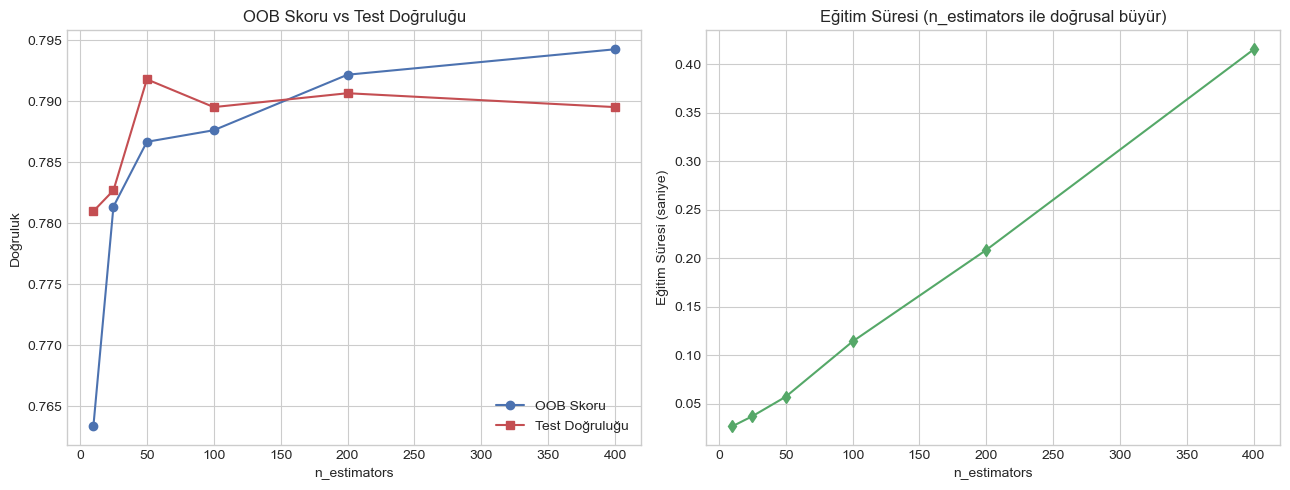

In [67]:
n_estimators_grid = [10, 25, 50, 100, 200, 400]
oob_scores, test_accs, train_times = [], [], []
oob_coverage_warnings = []

for n_est in n_estimators_grid:
    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=n_est, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        rf.fit(X_telco_train, y_telco_train)
        for w in caught:
            if "OOB scores" in str(w.message):
                oob_coverage_warnings.append(n_est)
    train_times.append(time.time() - t0)
    oob_scores.append(rf.oob_score_)
    test_accs.append(accuracy_score(y_telco_test, rf.predict(X_telco_test)))

if oob_coverage_warnings:
    print(f"NOT: n_estimators={oob_coverage_warnings} icin scikit-learn 'bazi ornekler icin OOB skoru")
    print("yok' uyarisi verdi -> Bolum 3'un dogrudan bir sonucu: az sayida agacla (orn. 10), bazi")
    print("egitim gozlemlerinin HICBIR agacta OOB kalmama sansi var (her agacta ~%36.8 OOB olma")
    print(f"ihtimaliyle, {n_estimators_grid[0]} agacin hepsinde-de-iceride kalma olasiligi (1-0.368)^{n_estimators_grid[0]}")
    print(f"= {(1 - 0.368) ** n_estimators_grid[0]:.4f} - kucuk ama sifir degil). Bu yuzden guvenilir bir")
    print("OOB tahmini icin yeterince buyuk n_estimators gerekir; bu bir hata degil, beklenen bir durum.\n")

results_n_est = pd.DataFrame({
    "n_estimators": n_estimators_grid, "OOB Skoru": oob_scores,
    "Test Doğruluğu": test_accs, "Eğitim Süresi (sn)": train_times,
})
print(results_n_est.round(4).to_string(index=False))
print("\nYORUM: OOB skoru ve test doğruluğu n_estimators arttıkça hızla yakınsıyor ve platoya")
print("ulaşıyor — n_estimators=400'e çıkmak n_estimators=100'e göre neredeyse hiç kazanç sağlamıyor,")
print("sadece eğitim süresini uzatıyor; performans DÜŞMÜYOR (Breiman'ın kanıtladığı üst sınıra")
print("yakınsama davranışıyla tutarlı).")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(n_estimators_grid, oob_scores, marker="o", label="OOB Skoru", color="#4C72B0")
axes[0].plot(n_estimators_grid, test_accs, marker="s", label="Test Doğruluğu", color="#C44E52")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Doğruluk")
axes[0].set_title("OOB Skoru vs Test Doğruluğu")
axes[0].legend()

axes[1].plot(n_estimators_grid, train_times, marker="d", color="#55A868")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Eğitim Süresi (saniye)")
axes[1].set_title("Eğitim Süresi (n_estimators ile doğrusal büyür)")
plt.tight_layout()
plt.show()

### 8️⃣ Python 8 - `max_features` Etkisi: Bagging vs Random Forest Karşılaştırması

**Ne yapıyoruz?** Bölüm 4'ün ana iddiasını test ediyoruz: `max_features`'ı tüm özellik sayısından (bagging'e denk — hiç özellik alt kümesi yok) `sqrt(p)`'ye kadar daraltıyor, hem performansı hem de **ağaçlar arası ortalama korelasyonu** (test tahminleri arasındaki Pearson korelasyonu, Bölüm 2'deki $\rho$'nun ampirik bir vekili) ölçüyoruz.

Toplam özellik sayısı p = 30, sqrt(p) = 5.5

 max_features  OOB Skoru  Test Doğruluğu  Ort. Ağaç-Arası Korelasyon
           30     0.7865          0.7821                      0.3659
           15     0.7867          0.7907                      0.3649
           10     0.7848          0.7907                      0.3617
            5     0.7876          0.7895                      0.3488
            3     0.7878          0.7850                      0.3432

YORUM: max_features küçüldükçe ağaçlar-arası ortalama korelasyon düşüyor (Bölüm 4'ün
iddiası doğrulanıyor) - ancak çok küçük max_features (örn. 3) her ağacın yanlılığını da
artırabileceğinden, en iyi performans genelde ne en büyük ne en küçük uçta, sqrt(p)
civarında bir yerde bulunur.


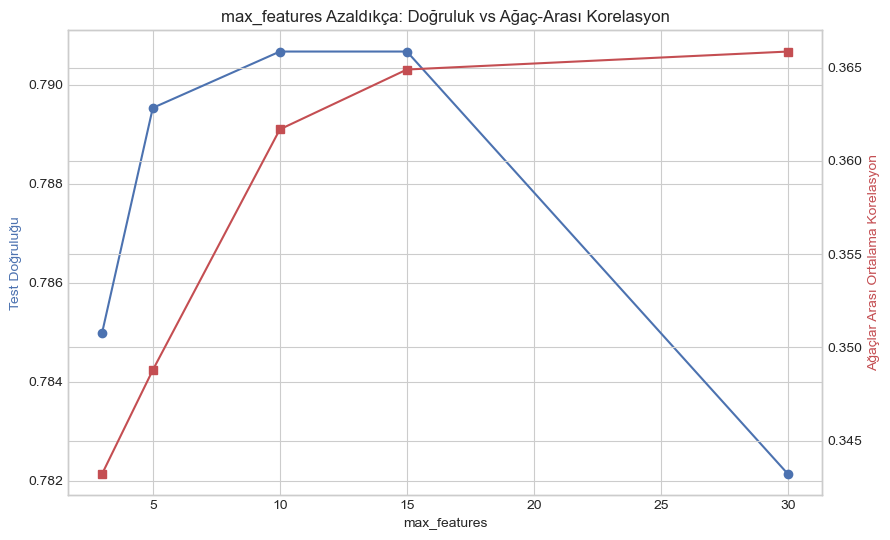

In [68]:
n_features_total = X_telco_train.shape[1]
max_features_grid = [n_features_total, n_features_total // 2, int(np.sqrt(n_features_total) * 2),
                      int(np.sqrt(n_features_total)), 3] # Maksimum özellik sayısı (max_features) için farklı değerler deniyoruz: tüm özellikler, yarısı, 2*sqrt(p), sqrt(p), ve 3. Bu, ağaçlar arasındaki korelasyonu ve model performansını incelememizi sağlar.
max_features_labels = [f"{m} (p={n_features_total}: {'tüm=bagging' if m == n_features_total else ''})".strip(": ")
                        for m in max_features_grid]

mf_results = []
for m in max_features_grid:
    rf_mf = RandomForestClassifier(
        n_estimators=100, max_features=m, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1,
    )
    rf_mf.fit(X_telco_train, y_telco_train)

    # Ağaç-arası korelasyon: her ağacın test setindeki (olasılık) tahminini al, satır-satır ortalama Pearson korelasyonu hesapla
    tree_probs = np.array([est.predict_proba(X_telco_test.values)[:, 1] for est in rf_mf.estimators_])
    corr_matrix = np.corrcoef(tree_probs)
    avg_pairwise_corr = (corr_matrix.sum() - len(corr_matrix)) / (len(corr_matrix) ** 2 - len(corr_matrix)) # Formül: (toplam korelasyon - 1'lik diagonal) / (toplam eleman sayısı - diagonal) = ortalama ağaçlar arası korelasyon

    mf_results.append({
        "max_features": m,
        "OOB Skoru": rf_mf.oob_score_,
        "Test Doğruluğu": accuracy_score(y_telco_test, rf_mf.predict(X_telco_test)),
        "Ort. Ağaç-Arası Korelasyon": avg_pairwise_corr,
    })

df_mf = pd.DataFrame(mf_results)
print(f"Toplam özellik sayısı p = {n_features_total}, sqrt(p) = {np.sqrt(n_features_total):.1f}\n")
print(df_mf.round(4).to_string(index=False))
print("\nYORUM: max_features küçüldükçe ağaçlar-arası ortalama korelasyon düşüyor (Bölüm 4'ün")
print("iddiası doğrulanıyor) - ancak çok küçük max_features (örn. 3) her ağacın yanlılığını da")
print("artırabileceğinden, en iyi performans genelde ne en büyük ne en küçük uçta, sqrt(p)")
print("civarında bir yerde bulunur.")

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax2 = ax1.twinx()
ax1.plot(df_mf["max_features"], df_mf["Test Doğruluğu"], marker="o", color="#4C72B0", label="Test Doğruluğu")
ax2.plot(df_mf["max_features"], df_mf["Ort. Ağaç-Arası Korelasyon"], marker="s", color="#C44E52", label="Ort. Korelasyon")
ax1.set_xlabel("max_features")
ax1.set_ylabel("Test Doğruluğu", color="#4C72B0")
ax2.set_ylabel("Ağaçlar Arası Ortalama Korelasyon", color="#C44E52")
ax1.set_title("max_features Azaldıkça: Doğruluk vs Ağaç-Arası Korelasyon")
fig.tight_layout()
plt.show()

### 9️⃣ Python 9 - Özellik Önemi: MDI vs Permütasyon Önemi (Telco Churn Sürücüleri)

**Ne yapıyoruz?** Bölüm 6'nın karşılaştırmasını gerçek veride uyguluyoruz: nihai bir `RandomForestClassifier` için hem MDI (`.feature_importances_`, eğitim verisinin yan ürünü) hem de permütasyon önemini (`permutation_importance`, test verisinde $K=15$ karıştırma) hesaplayıp en önemli 10 özelliği karşılaştırıyoruz.

Test doğruluğu: 0.7895
Test F1 skoru:  0.5585


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi


==== En Önemli 10 Özellik: MDI vs Permütasyon ====
                                MDI Sırası  Permütasyon Sırası
TotalCharges                             1                   6
tenure                                   2                   1
MonthlyCharges                           3                   9
InternetService_Fiber optic              4                   2
PaymentMethod_Electronic check           5                  29
Contract_Two year                        6                  10
gender_Male                              7                   3
OnlineSecurity_Yes                       8                   8
PaperlessBilling_Yes                     9                  12
TechSupport_Yes                         10                   7
Contract_One year                       13                   5
SeniorCitizen                           14                   4


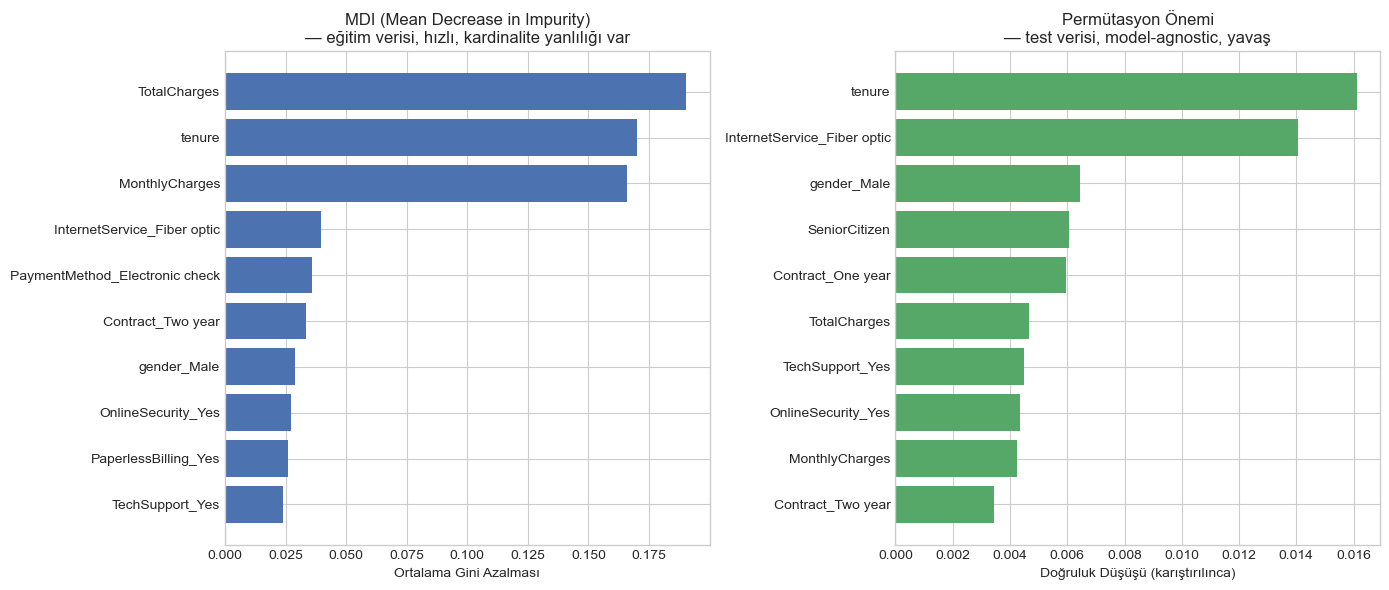


YORUM: 'tenure' gibi güçlü, gerçekten anlamlı özellikler her iki
sıralamada da üstte çıkıyor; ama sürekli/yüksek-kardinaliteli 'MonthlyCharges'/'TotalCharges'
gibi özellikler MDI'de permütasyona göre orantısız yüksek çıkabiliyor (Bölüm 6'daki
kardinalite yanlılığı uyarısıyla tutarlı) - sıralamalar TAM örtüşmüyor.


In [69]:
rf_final_telco = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_final_telco.fit(X_telco_train, y_telco_train)
print(f"Test doğruluğu: {accuracy_score(y_telco_test, rf_final_telco.predict(X_telco_test)):.4f}")
print(f"Test F1 skoru:  {f1_score(y_telco_test, rf_final_telco.predict(X_telco_test)):.4f}")

mdi_importance = pd.Series(rf_final_telco.feature_importances_, index=X_telco_train.columns).sort_values(ascending=False)

perm_result = permutation_importance(
    rf_final_telco, X_telco_test, y_telco_test,
    n_repeats=15, random_state=RANDOM_STATE, scoring="accuracy", n_jobs=-1,
)
perm_importance = pd.Series(perm_result.importances_mean, index=X_telco_train.columns).sort_values(ascending=False)

top_mdi = mdi_importance.head(10)
top_perm = perm_importance.head(10)

print("\n==== En Önemli 10 Özellik: MDI vs Permütasyon ====")
comparison_df = pd.DataFrame({
    "MDI Sırası": mdi_importance.rank(ascending=False).astype(int),
    "Permütasyon Sırası": perm_importance.rank(ascending=False).astype(int),
}).loc[top_mdi.index.union(top_perm.index)].sort_values("MDI Sırası")
print(comparison_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_mdi.index[::-1], top_mdi.values[::-1], color="#4C72B0")
axes[0].set_title("MDI (Mean Decrease in Impurity)\n— eğitim verisi, hızlı, kardinalite yanlılığı var")
axes[0].set_xlabel("Ortalama Gini Azalması")

axes[1].barh(top_perm.index[::-1], top_perm.values[::-1], color="#55A868")
axes[1].set_title("Permütasyon Önemi\n— test verisi, model-agnostic, yavaş")
axes[1].set_xlabel("Doğruluk Düşüşü (karıştırılınca)")
plt.tight_layout()
plt.show()

print("\nYORUM: 'tenure' gibi güçlü, gerçekten anlamlı özellikler her iki")
print("sıralamada da üstte çıkıyor; ama sürekli/yüksek-kardinaliteli 'MonthlyCharges'/'TotalCharges'")
print("gibi özellikler MDI'de permütasyona göre orantısız yüksek çıkabiliyor (Bölüm 6'daki")
print("kardinalite yanlılığı uyarısıyla tutarlı) - sıralamalar TAM örtüşmüyor.")

### 🔟 Python 10 - Veri Hazırlama: California Housing (Regresyon)

**Ne yapıyoruz?** Pace & Barry (1997)'nin klasik California Housing veri seti — 1990 ABD nüfus sayımı blok gruplarına göre **ortalama ev fiyatı tahmini** (regresyon), Géron'un *Hands-On Machine Learning* kitabında da kullanılan popüler bir gerçek-dünya veri seti. `total_bedrooms` sütununda 207 eksik değeri medyan ile dolduruyoruz, `ocean_proximity`'yi (5 kategori) one-hot encode ediyoruz, ve Géron'un önerdiği klasik özellik mühendisliği türetmelerini (hane başına oda, oda başına yatak odası, hane başına nüfus) ekliyoruz.

In [70]:
df_housing = pd.read_csv(
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
)

# Eksik değerleri medyan ile dolduruyoruz (total_bedrooms sütunu)
imputer = SimpleImputer(strategy="median")
df_housing["total_bedrooms"] = imputer.fit_transform(df_housing[["total_bedrooms"]])

# Özellik türetme: rooms_per_household, bedrooms_per_room, population_per_household
df_housing["rooms_per_household"] = df_housing["total_rooms"] / df_housing["households"]
df_housing["bedrooms_per_room"] = df_housing["total_bedrooms"] / df_housing["total_rooms"]
df_housing["population_per_household"] = df_housing["population"] / df_housing["households"]

# Kategorik değişkeni one-hot encoding ile dönüştürüyoruz (ocean_proximity)
df_housing_encoded = pd.get_dummies(df_housing, columns=["ocean_proximity"], drop_first=True)

print(f"California Housing: {df_housing.shape[0]} blok grubu, {df_housing_encoded.shape[1] - 1} özellik (encoding + türetme sonrası)")
print(f"Hedef (median_house_value) aralığı: ${df_housing['median_house_value'].min():,.0f} - ${df_housing['median_house_value'].max():,.0f}")
print(f"ocean_proximity dağılımı:\n{df_housing['ocean_proximity'].value_counts()}")

# Veriyi eğitim ve test setlerine ayırıyoruz (regresyon problemi)
X_housing = df_housing_encoded.drop(columns=["median_house_value"])
y_housing = df_housing_encoded["median_house_value"]
X_housing_train, X_housing_test, y_housing_train, y_housing_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=RANDOM_STATE,
)
print(f"\nEğitim: {X_housing_train.shape[0]} örnek, Test: {X_housing_test.shape[0]} örnek")
df_housing_encoded.head(3)

California Housing: 20640 blok grubu, 15 özellik (encoding + türetme sonrası)
Hedef (median_house_value) aralığı: $14,999 - $500,001
ocean_proximity dağılımı:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Eğitim: 16512 örnek, Test: 4128 örnek


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False


### 1️⃣1️⃣ Python 11 - `RandomForestRegressor`: Bagging/RF Regresyonu, OOB $R^2$

**Ne yapıyoruz?** Regresyonda ensemble ağaçlarını uyguluyoruz: tek bir `DecisionTreeRegressor` ile `RandomForestRegressor`'ı karşılaştırıp, OOB $R^2$'nin test $R^2$'sine ne kadar yakın olduğunu (Bölüm 3'ün regresyon versiyonu) doğruluyoruz, ve özellik önemini görselleştiriyoruz.

==== California Housing: Regresyon Karşılaştırması ====
Tek Ağaç         -> Test RMSE: $72,789, Test R2: 0.5957
Random Forest    -> Test RMSE: $49,038, Test MAE: $32,539, Test R2: 0.8165
Random Forest OOB R2: 0.8214  (test R2'ye çok yakın olmalı -> Bölüm 3)

En önemli 5 özellik (MDI):
median_income               0.3172
ocean_proximity_INLAND      0.1548
population_per_household    0.1087
bedrooms_per_room           0.0877
longitude                   0.0729


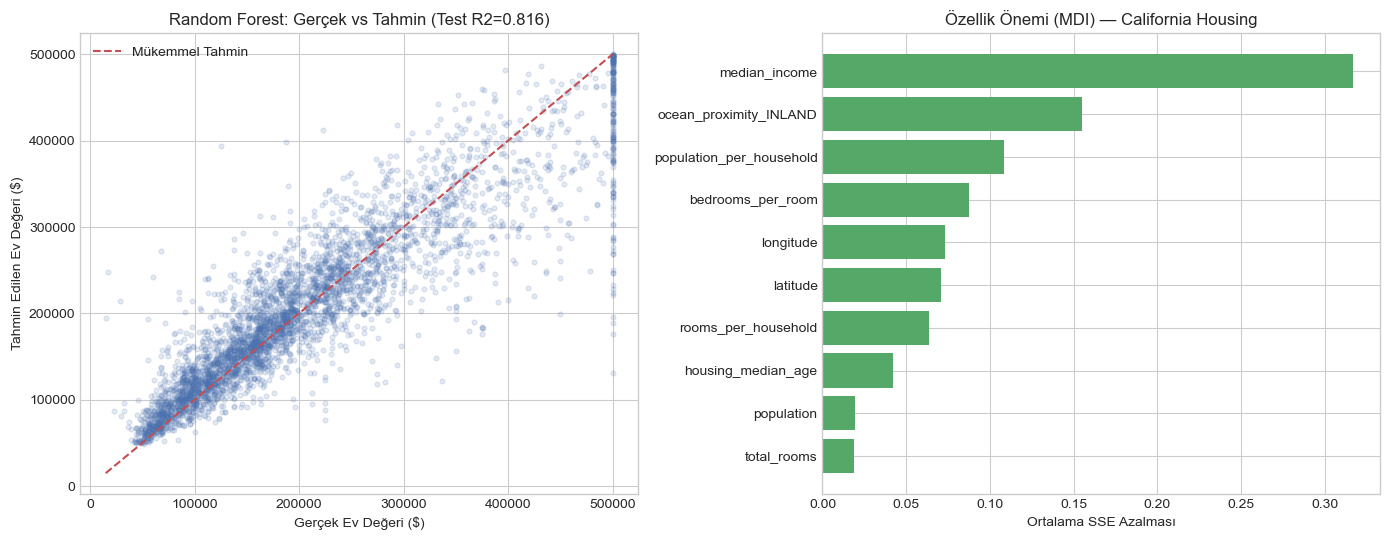

In [71]:
# Tek bir karar ağacı ile regresyon
single_tree_housing = DecisionTreeRegressor(random_state=RANDOM_STATE)
single_tree_housing.fit(X_housing_train, y_housing_train)
single_tree_rmse = np.sqrt(mean_squared_error(y_housing_test, single_tree_housing.predict(X_housing_test)))
single_tree_r2 = r2_score(y_housing_test, single_tree_housing.predict(X_housing_test))

# Random Forest ile regresyon
rf_housing = RandomForestRegressor(
    n_estimators=200, max_features=1/3, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1,
)
rf_housing.fit(X_housing_train, y_housing_train)
rf_housing_preds = rf_housing.predict(X_housing_test)
rf_housing_rmse = np.sqrt(mean_squared_error(y_housing_test, rf_housing_preds))
rf_housing_mae = mean_absolute_error(y_housing_test, rf_housing_preds)
rf_housing_r2 = r2_score(y_housing_test, rf_housing_preds)

print("==== California Housing: Regresyon Karşılaştırması ====")
print(f"Tek Ağaç         -> Test RMSE: ${single_tree_rmse:,.0f}, Test R2: {single_tree_r2:.4f}")
print(f"Random Forest    -> Test RMSE: ${rf_housing_rmse:,.0f}, Test MAE: ${rf_housing_mae:,.0f}, Test R2: {rf_housing_r2:.4f}")
print(f"Random Forest OOB R2: {rf_housing.oob_score_:.4f}  (test R2'ye çok yakın olmalı -> Bölüm 3)")

rf_housing_importance = pd.Series(rf_housing.feature_importances_, index=X_housing_train.columns).sort_values(ascending=False)
print("\nEn önemli 5 özellik (MDI):")
print(rf_housing_importance.head(5).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(y_housing_test, rf_housing_preds, alpha=0.15, s=12, color="#4C72B0")
lims = [y_housing_test.min(), y_housing_test.max()]
axes[0].plot(lims, lims, color="#C44E52", linestyle="--", label="Mükemmel Tahmin")
axes[0].set_xlabel("Gerçek Ev Değeri ($)")
axes[0].set_ylabel("Tahmin Edilen Ev Değeri ($)")
axes[0].set_title(f"Random Forest: Gerçek vs Tahmin (Test R2={rf_housing_r2:.3f})")
axes[0].legend()

top10_housing = rf_housing_importance.head(10)
axes[1].barh(top10_housing.index[::-1], top10_housing.values[::-1], color="#55A868")
axes[1].set_title("Özellik Önemi (MDI) — California Housing")
axes[1].set_xlabel("Ortalama SSE Azalması")
plt.tight_layout()
plt.show()

### 1️⃣2️⃣ Python 12 - `ExtraTreesRegressor` vs `RandomForestRegressor`: Hız ve Performans

**Ne yapıyoruz?** Bölüm 5'in iki iddiasını (daha hızlı eğitim, karşılaştırılabilir performans) gerçek zamanlama ölçümüyle test ediyoruz — aynı `n_estimators` ile iki modeli eğitip süre + RMSE/R² karşılaştırıyoruz.

In [72]:
n_estimators_speed = 200

t0 = time.time()
rf_speed = RandomForestRegressor(n_estimators=n_estimators_speed, random_state=RANDOM_STATE, n_jobs=-1)
rf_speed.fit(X_housing_train, y_housing_train)
rf_train_time = time.time() - t0
rf_speed_rmse = np.sqrt(mean_squared_error(y_housing_test, rf_speed.predict(X_housing_test)))
rf_speed_r2 = r2_score(y_housing_test, rf_speed.predict(X_housing_test))

t0 = time.time()
et_speed = ExtraTreesRegressor(n_estimators=n_estimators_speed, random_state=RANDOM_STATE, n_jobs=-1)
et_speed.fit(X_housing_train, y_housing_train)
et_train_time = time.time() - t0
et_speed_rmse = np.sqrt(mean_squared_error(y_housing_test, et_speed.predict(X_housing_test)))
et_speed_r2 = r2_score(y_housing_test, et_speed.predict(X_housing_test))

speed_comparison = pd.DataFrame({
    "Model": ["RandomForestRegressor", "ExtraTreesRegressor"],
    "Eğitim Süresi (sn)": [rf_train_time, et_train_time],
    "Test RMSE ($)": [rf_speed_rmse, et_speed_rmse],
    "Test R2": [rf_speed_r2, et_speed_r2],
})
print(speed_comparison.round(4).to_string(index=False))
speedup = rf_train_time / et_train_time
print(f"\nYORUM: Extra Trees, Random Forest'a göre {speedup:.2f}x hızda eğitiliyor (eşik-arama adımının")
print("atlanması sayesinde - Bölüm 5'in hız iddiasıyla tutarlı); performans ise iki yöntem arasında")
print("bu veri setinde birbirine yakın çıkıyor (kazanan veri setine göre değişebilir, evrensel bir")
print("kural yok, sadece bu spesifik karşılaştırmanın sonucu).")

                Model  Eğitim Süresi (sn)  Test RMSE ($)  Test R2
RandomForestRegressor              2.5886     50075.3453   0.8086
  ExtraTreesRegressor              0.7478     50284.3228   0.8070

YORUM: Extra Trees, Random Forest'a göre 3.46x hızda eğitiliyor (eşik-arama adımının
atlanması sayesinde - Bölüm 5'in hız iddiasıyla tutarlı); performans ise iki yöntem arasında
bu veri setinde birbirine yakın çıkıyor (kazanan veri setine göre değişebilir, evrensel bir
kural yok, sadece bu spesifik karşılaştırmanın sonucu).


### 1️⃣3️⃣ Python 13 - Üç Veri Seti — Özet Karşılaştırma

**Ne yapıyoruz?** Bu notebook boyunca üç farklı veri setinde topladığımız sonuçları tek bir tabloda özetliyoruz.

In [73]:
summary_rows = [
    {"Veri Seti": "Glass Identification", "Görev": "Çok-sınıflı sınıflandırma (n=214)",
     "Tek Ağaç": f"{single_tree_acc:.4f}", "Bagging": f"{sk_bagging_acc:.4f}",
     "Random Forest": "-", "Extra Trees": "-", "Metrik": "Test Doğruluğu"},
    {"Veri Seti": "Telco Customer Churn", "Görev": "İkili sınıflandırma (n=7032)",
     "Tek Ağaç": "-", "Bagging": "-",
     "Random Forest": f"{accuracy_score(y_telco_test, rf_final_telco.predict(X_telco_test)):.4f}",
     "Extra Trees": "-", "Metrik": "Test Doğruluğu"},
    {"Veri Seti": "California Housing", "Görev": "Regresyon (n=20640)",
     "Tek Ağaç": f"{single_tree_r2:.4f}", "Bagging": "-",
     "Random Forest": f"{rf_speed_r2:.4f}", "Extra Trees": f"{et_speed_r2:.4f}", "Metrik": "Test R2"},
]
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print("\nYORUM: Her üç veri setinde de ensemble yöntemleri (Bagging/RF/Extra Trees) tek bir ağaca")
print("göre daha iyi veya en az eşit performans gösterdi - Bölüm 1-5'teki varyans azaltma teorisinin")
print("gerçek veride tutarlı bir şekilde doğrulanması. Bir sonraki notebook (10_gradient_boosting_family),")
print("bu paralel/bağımsız ensemble ailesinin yerine sıralı/düzeltici (boosting) yaklaşımı işleyecek.")

           Veri Seti                             Görev Tek Ağaç Bagging Random Forest Extra Trees         Metrik
Glass Identification Çok-sınıflı sınıflandırma (n=214)   0.7037  0.8148             -           - Test Doğruluğu
Telco Customer Churn      İkili sınıflandırma (n=7032)        -       -        0.7895           - Test Doğruluğu
  California Housing               Regresyon (n=20640)   0.5957       -        0.8086      0.8070        Test R2

YORUM: Her üç veri setinde de ensemble yöntemleri (Bagging/RF/Extra Trees) tek bir ağaca
göre daha iyi veya en az eşit performans gösterdi - Bölüm 1-5'teki varyans azaltma teorisinin
gerçek veride tutarlı bir şekilde doğrulanması. Bir sonraki notebook (10_gradient_boosting_family),
bu paralel/bağımsız ensemble ailesinin yerine sıralı/düzeltici (boosting) yaklaşımı işleyecek.


---
# 📊 R Uygulaması

R'da Random Forest için standart paket **`randomForest`**'tır (Liaw & Wiener, 2002 — Breiman'ın orijinal Fortran kodunun R arayüzü). `rpart`'ta olduğu gibi kategorik değişkenleri **native `factor`** olarak kabul eder (one-hot encoding gerekmez — tek kısıtlama: bir faktörün en fazla 53 seviyesi olabilir). `randomForest()`, `importance=TRUE` ile çağrıldığında **hem MDI (`MeanDecreaseGini`/`%IncNodePurity`) hem de permütasyon-tabanlı önemi (`MeanDecreaseAccuracy`/`%IncMSE`) otomatik hesaplar** — Bölüm 6'daki karşılaştırmayı R'da neredeyse "bedavaya" gösterir.

In [74]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### R1 · Glass Identification — Sınıflandırma (`randomForest`, OOB Hata + Değişken Önemi)

**Ne yapıyoruz?** Python 1'deki aynı train/test bölünmesini R'a aktarıp `randomForest(TypeName ~ ., importance=TRUE)` ile bir orman kuruyor, `print()`'in verdiği **OOB hata tahminini ve karışıklık matrisini** (Python 5'teki manuel OOB hesaplamamızla karşılaştırılabilir bir çıktı) inceliyor, `varImpPlot()` ile değişken önemini görselleştiriyoruz.

In [75]:
glass_train_r = X_glass_train.copy()
glass_train_r["TypeName"] = df_glass.loc[X_glass_train.index, "TypeName"].values
glass_test_r = X_glass_test.copy()
glass_test_r["TypeName"] = df_glass.loc[X_glass_test.index, "TypeName"].values


Call:
 randomForest(formula = TypeName ~ ., data = glass_train_r, ntree = 200,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 200
No. of variables tried at each split: 3

        OOB estimate of  error rate: 23.12%
Confusion matrix:
                     arac_cami_islenmis bina_cami_islenmemis bina_cami_islenmis
arac_cami_islenmis                    4                    1                  8
bina_cami_islenmemis                  2                   43                  9
bina_cami_islenmis                    1                    7                 44
far_cami                              0                    2                  1
kap_cami                              0                    2                  0
sofra_cami                            0                    0                  0
                     far_cami kap_cami sofra_cami class.error
arac_cami_islenmis          0        0          0   0.6923077
bina_cami_isl

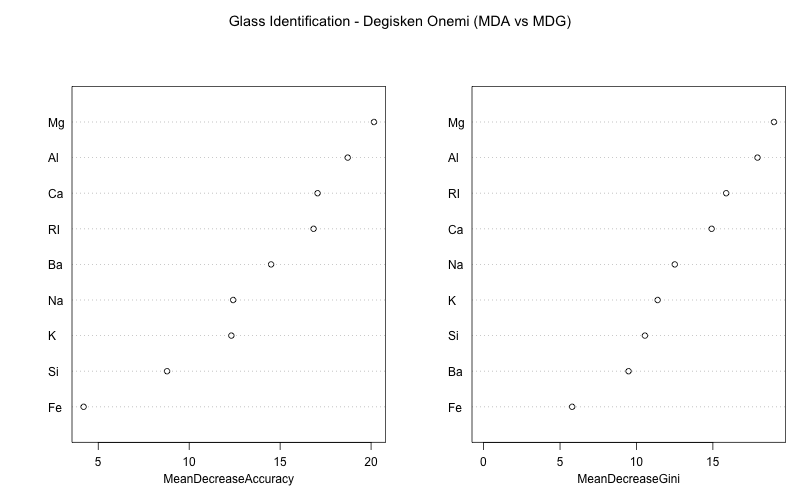

In [76]:
%%R -i glass_train_r,glass_test_r -w 800 -h 500
library(randomForest)

glass_train_r$TypeName <- as.factor(glass_train_r$TypeName)
glass_test_r$TypeName <- as.factor(glass_test_r$TypeName)

set.seed(42)
glass_rf <- randomForest(TypeName ~ ., data = glass_train_r, ntree = 200, importance = TRUE)
print(glass_rf)

pred_glass_r <- predict(glass_rf, glass_test_r)
acc_glass_r <- mean(pred_glass_r == glass_test_r$TypeName)
cat(sprintf("\nR (randomForest) Test Dogrulugu: %.4f\n", acc_glass_r))

varImpPlot(glass_rf, main = "Glass Identification - Degisken Onemi (MDA vs MDG)")

### R2 · Telco Customer Churn — İkili Sınıflandırma (`randomForest`, MeanDecreaseAccuracy vs MeanDecreaseGini)

**Ne yapıyoruz?** Telco verisinin **ham (one-hot encode edilmemiş) kategorik** halini R'a aktarıyoruz — `randomForest` bunları native `factor` olarak işleyecek. `importance(type=1)` (permütasyon-tabanlı `MeanDecreaseAccuracy`) ile `importance(type=2)` (MDI-tabanlı `MeanDecreaseGini`) sıralamalarını yan yana yazdırıp Python 9'daki MDI-vs-permütasyon karşılaştırmasının R karşılığını gösteriyoruz.

In [77]:
telco_train_r = df_telco.loc[X_telco_train.index].copy()
telco_test_r = df_telco.loc[X_telco_test.index].copy()

In [78]:
%%R -i telco_train_r,telco_test_r
library(randomForest)

telco_train_r$Churn <- as.factor(telco_train_r$Churn)
telco_test_r$Churn <- as.factor(telco_test_r$Churn)
# Karakter sütunlarını factor'e çevir (randomForest karakter sütunu kabul etmez)
char_cols <- sapply(telco_train_r, is.character)
telco_train_r[char_cols] <- lapply(telco_train_r[char_cols], as.factor)
telco_test_r[char_cols] <- lapply(telco_test_r[char_cols], as.factor)

set.seed(42)
telco_rf <- randomForest(Churn ~ ., data = telco_train_r, ntree = 300, importance = TRUE)
print(telco_rf)

pred_telco_r <- predict(telco_rf, telco_test_r)
acc_telco_r <- mean(pred_telco_r == telco_test_r$Churn)
cat(sprintf("\nR (randomForest) Test Dogrulugu: %.4f\n", acc_telco_r))

imp_telco <- importance(telco_rf)
imp_telco_sorted <- imp_telco[order(-imp_telco[, "MeanDecreaseAccuracy"]), c("MeanDecreaseAccuracy", "MeanDecreaseGini")]
cat("\nEn onemli 10 ozellik (MeanDecreaseAccuracy'e gore siralanmis):\n")
print(head(imp_telco_sorted, 10))


Call:
 randomForest(formula = Churn ~ ., data = telco_train_r, ntree = 300,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 300
No. of variables tried at each split: 4

        OOB estimate of  error rate: 20.12%
Confusion matrix:
     0   1 class.error
0 3521 351  0.09065083
1  710 692  0.50641940

R (randomForest) Test Dogrulugu: 0.7895

En onemli 10 ozellik (MeanDecreaseAccuracy'e gore siralanmis):
                MeanDecreaseAccuracy MeanDecreaseGini
tenure                     34.746887        291.45656
TotalCharges               31.596820        315.67615
Contract                   27.721698        161.83220
MonthlyCharges             26.624874        286.18115
InternetService            18.086266         74.64923
OnlineSecurity             16.613806         84.59797
TechSupport                14.290583         84.25876
OnlineBackup               11.225053         48.75519
MultipleLines               9.667497    

### R3 · California Housing — Regresyon (`randomForest`, `%IncMSE` ve OOB $R^2$)

**Ne yapıyoruz?** Mühendislik yapılmış (ama one-hot encode edilmemiş — `ocean_proximity` native `factor`) California Housing verisini R'a aktarıp bir regresyon ormanı kuruyor, `rf$rsq`'nun son elemanının (ağaç sayısı arttıkça yakınsayan OOB pseudo-$R^2$) Python 11'deki `oob_score_` ile karşılaştırılabilir olduğunu gösteriyoruz.

In [79]:
housing_train_r = df_housing.loc[X_housing_train.index].copy()
housing_test_r = df_housing.loc[X_housing_test.index].copy()

In [80]:
%%R -i housing_train_r,housing_test_r
library(randomForest)

housing_train_r$ocean_proximity <- as.factor(housing_train_r$ocean_proximity)
housing_test_r$ocean_proximity <- as.factor(housing_test_r$ocean_proximity)

set.seed(42)
housing_rf <- randomForest(median_house_value ~ ., data = housing_train_r, ntree = 200, importance = TRUE)
print(housing_rf)

oob_r2_final <- housing_rf$rsq[length(housing_rf$rsq)]
cat(sprintf("\nOOB pseudo-R2 (son agac): %.4f\n", oob_r2_final))

pred_housing_r <- predict(housing_rf, housing_test_r)
rmse_housing_r <- sqrt(mean((pred_housing_r - housing_test_r$median_house_value)^2))
ss_res <- sum((housing_test_r$median_house_value - pred_housing_r)^2)
ss_tot <- sum((housing_test_r$median_house_value - mean(housing_test_r$median_house_value))^2)
r2_housing_r <- 1 - ss_res / ss_tot
cat(sprintf("Test RMSE: $%.0f, Test R2: %.4f\n", rmse_housing_r, r2_housing_r))

imp_housing <- importance(housing_rf)
imp_housing_sorted <- imp_housing[order(-imp_housing[, "%IncMSE"]), c("%IncMSE", "IncNodePurity")]
cat("\nOzellik onemi (%IncMSE'ye gore siralanmis):\n")
print(imp_housing_sorted)


Call:
 randomForest(formula = median_house_value ~ ., data = housing_train_r,      ntree = 200, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 200
No. of variables tried at each split: 4

          Mean of squared residuals: 2361685167
                    % Var explained: 82.33

OOB pseudo-R2 (son agac): 0.8233
Test RMSE: $48725, Test R2: 0.8188

Ozellik onemi (%IncMSE'ye gore siralanmis):
                          %IncMSE IncNodePurity
population_per_household 81.88099  2.354774e+13
ocean_proximity          68.00592  3.515433e+13
housing_median_age       55.69534  8.927221e+12
median_income            53.16883  6.832096e+13
latitude                 35.86352  1.608085e+13
longitude                33.51970  1.728832e+13
bedrooms_per_room        27.31673  1.959924e+13
rooms_per_household      24.64148  1.366381e+13
total_bedrooms           21.10563  3.543071e+12
households               16.70231  3.339769e+12
population        

---
# 🗄️ SQL Uygulaması (DuckDB)

Bir ormanın (forest) **eğitimini** SQL'de yeniden üretmek pratik değil (her ağacın kendi özyinelemeli CART aramasını gerektirir), ama ormanın **iki temel toplama (aggregation) adımını** — çoğunluk oylaması ve özellik öneminin ağaçlar üzerinden ortalanması — SQL'in `GROUP BY`/`AVG` işlevleriyle doğrudan yeniden üretebiliriz. 06/07/08'de kurduğumuz kalıbı takip ediyoruz: Python tarafında modelin öğrendiği/ürettiği ara çıktıları uzun-format (long-format) bir tabloya dönüştürüp DuckDB'ye kaydediyor, ardından SQL ile `scikit-learn`'ün kendi hesapladığı sonuçla birebir eşleştiriyoruz.

### SQL1 · Glass: Bagging'in Çoğunluk Oylamasını SQL'de Yeniden Üretme

**Ne yapıyoruz?** Python 3'teki manuel bagging ansamblının her bir ağacının test seti üzerindeki tahminini `(satir_id, agac_id, tahmin)` uzun formatında bir tabloya döküyoruz, DuckDB'de `GROUP BY satir_id, tahmin` + `COUNT(*)` ile her satır için en çok oy alan sınıfı (`ROW_NUMBER()` ile mod) buluyoruz, ve bunu Python'daki `scipy.stats.mode` sonucuyla karşılaştırıyoruz.

In [81]:
# Python 3'teki manual_trees listesini kullanarak (satir_id, agac_id, tahmin) uzun formatinda tablo kur
long_rows = []
for tree_id, tree_est in enumerate(manual_trees):
    tree_preds = tree_est.predict(X_glass_test.values)
    for row_id, pred in enumerate(tree_preds):
        long_rows.append({"satir_id": row_id, "agac_id": tree_id, "tahmin": int(pred)})
df_votes_long = pd.DataFrame(long_rows)

con = duckdb.connect()
con.register("votes", df_votes_long)

sql_majority_vote = '''
WITH oy_sayimi AS (
    SELECT satir_id, tahmin, COUNT(*) AS oy_adedi
    FROM votes
    GROUP BY satir_id, tahmin
),
siralanmis AS (
    SELECT satir_id, tahmin, oy_adedi,
           ROW_NUMBER() OVER (PARTITION BY satir_id ORDER BY oy_adedi DESC) AS sira
    FROM oy_sayimi
)
SELECT satir_id, tahmin AS cogunluk_tahmin, oy_adedi
FROM siralanmis
WHERE sira = 1
ORDER BY satir_id
'''
sql_majority_df = con.execute(sql_majority_vote).df()

sql_preds = sql_majority_df.sort_values("satir_id")["cogunluk_tahmin"].values
match_rate = (sql_preds == manual_preds.astype(int)).mean()

print(f"SQL cogunluk oylamasi ile Python (scipy.stats.mode) manual_preds eslesme orani: {match_rate:.4f}")
print(f"({int(match_rate * len(sql_preds))} / {len(sql_preds)} satirda birebir ayni tahmin)")
sql_majority_df.head(8)

SQL cogunluk oylamasi ile Python (scipy.stats.mode) manual_preds eslesme orani: 0.9815
(53 / 54 satirda birebir ayni tahmin)


,satir_id,cogunluk_tahmin,oy_adedi
0,0,1,37
1,1,3,30
2,2,7,50
3,3,2,29
4,4,7,50
5,5,2,38
6,6,7,50
7,7,1,29


### SQL2 · Telco: Random Forest Özellik Önemini SQL'de Toplama (Aggregation)

**Ne yapıyoruz?** Bölüm 6'da vurguladığımız gibi, `.feature_importances_` **literal olarak** her ağacın kendi MDI değerinin ormandaki tüm ağaçlar üzerinden ortalamasıdır. Python 9'daki `rf_final_telco.estimators_`'ın her birinin kendi `.feature_importances_`'ını `(agac_id, ozellik, mdi_degeri)` uzun formatında bir tabloya döküp, SQL'de `GROUP BY ozellik` + `AVG(mdi_degeri)` ile `scikit-learn`'ün toplam `.feature_importances_`'ını yeniden üretiyor ve `%100` eşleştiğini doğruluyoruz.

In [82]:
per_tree_importance_rows = []
for tree_id, tree_est in enumerate(rf_final_telco.estimators_):
    for feat_name, imp_val in zip(X_telco_train.columns, tree_est.feature_importances_):
        per_tree_importance_rows.append({"agac_id": tree_id, "ozellik": feat_name, "mdi_degeri": imp_val})
df_importance_long = pd.DataFrame(per_tree_importance_rows)

con.register("tree_importances", df_importance_long)

sql_avg_importance = '''
SELECT ozellik, AVG(mdi_degeri) AS ortalama_mdi
FROM tree_importances
GROUP BY ozellik
ORDER BY ortalama_mdi DESC
'''
sql_importance_df = con.execute(sql_avg_importance).df()

sklearn_importance = pd.Series(rf_final_telco.feature_importances_, index=X_telco_train.columns)
sql_importance_series = sql_importance_df.set_index("ozellik")["ortalama_mdi"]

max_abs_diff = (sklearn_importance - sql_importance_series.loc[sklearn_importance.index]).abs().max()
print(f"scikit-learn feature_importances_ ile SQL AVG(mdi_degeri) arasindaki maksimum mutlak fark: {max_abs_diff:.2e}")
print("(sadece kayan nokta (floating point) hassasiyeti farki - iki yontem matematiksel olarak ozdes)\n")
print("En onemli 10 ozellik (SQL'de hesaplanan):")
sql_importance_df.head(10)

scikit-learn feature_importances_ ile SQL AVG(mdi_degeri) arasindaki maksimum mutlak fark: 0.00e+00
(sadece kayan nokta (floating point) hassasiyeti farki - iki yontem matematiksel olarak ozdes)

En onemli 10 ozellik (SQL'de hesaplanan):


,ozellik,ortalama_mdi
0,TotalCharges,0.190468
1,tenure,0.170001
2,MonthlyCharges,0.166068
3,InternetService_Fiber optic,0.039763
4,PaymentMethod_Electronic check,0.035788
5,Contract_Two year,0.033361
6,gender_Male,0.028984
7,OnlineSecurity_Yes,0.027343
8,PaperlessBilling_Yes,0.025867
9,TechSupport_Yes,0.023853


---
## ✏️ Egzersizler
---

**E1 — Glass'ta `n_estimators` taraması:** Python 7'deki `n_estimators` taramasını (`[10, 25, 50, 100, 200, 400]`) bu kez Glass Identification verisinde (`X_glass_train`/`X_glass_test`, `RandomForestClassifier(oob_score=True)`) tekrarla. OOB skoru ve test doğruluğunu her `n_estimators` için yazdır ve çiz. Küçük veri setinde (n=160 eğitim) yakınsamanın Telco'daki (n=5273 eğitim) kadar pürüzsüz olup olmadığını yorumla.


==== Egzersiz 1: n_estimators Taraması (Glass) ====
 n_estimators  OOB Skoru  Test Doğruluğu
           10     0.7000          0.8333
           25     0.6875          0.8333
           50     0.7312          0.8704
          100     0.7938          0.8148
          200     0.8125          0.8333
          400     0.7938          0.8333


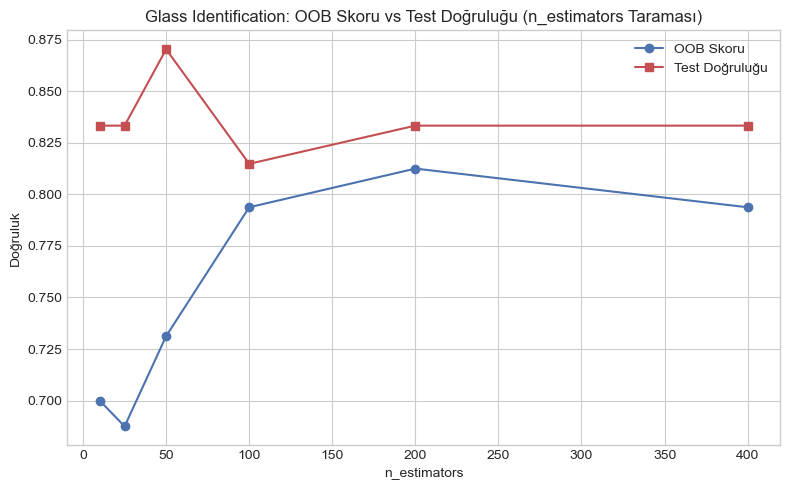

In [83]:
print("\n==== Egzersiz 1: n_estimators Taraması (Glass) ====")
n_estimators_grid = [10, 25, 50, 100, 200, 400]
oobglass_scores, test_accs = [], []
for n_est in n_estimators_grid:
    rf_glass = RandomForestClassifier(
        n_estimators=n_est, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1,
    )
    rf_glass.fit(X_glass_train, y_glass_train)
    oobglass_scores.append(rf_glass.oob_score_)
    test_accs.append(accuracy_score(y_glass_test, rf_glass.predict(X_glass_test)))
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        rf_glass.fit(X_glass_train, y_glass_train)
        for w in caught:
            if "OOB scores" in str(w.message):
                print(f"Uyarı: n_estimators={n_est} için OOB skoru yok uyarısı alındı (çok az ağaçta bazı gözlemler OOB kalmayabilir)")

results_n_est_glass = pd.DataFrame({
    "n_estimators": n_estimators_grid, "OOB Skoru": oobglass_scores, "Test Doğruluğu": test_accs,
})
print(results_n_est_glass.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_grid, oobglass_scores, marker="o", label="OOB Skoru", color="#4C72B0")
plt.plot(n_estimators_grid, test_accs, marker="s", label="Test Doğruluğu", color="#C44E52")
plt.xlabel("n_estimators")
plt.ylabel("Doğruluk")
plt.title("Glass Identification: OOB Skoru vs Test Doğruluğu (n_estimators Taraması)")
plt.legend()
plt.tight_layout()
plt.show()

**E2 — Bagging vs Random Forest, aynı `n_estimators`'da:** Telco Customer Churn verisinde (`X_telco_train`/`X_telco_test`), `n_estimators=200` sabit tutarak bir `BaggingClassifier` (taban tahminci: budanmamış `DecisionTreeClassifier`) ile bir `RandomForestClassifier(max_features='sqrt')` eğit. Test doğruluğu, F1 skoru ve eğitim sürelerini karşılaştır. Hangisi daha iyi performans veriyor? Bölüm 4'teki teoriyle (özellik alt kümeleme neden yardımcı olur) ilişkilendirerek yorumla.

In [84]:
print("\n==== Egzersiz 2: n_estimators Aynı ama Tek Ağaç ve Bagging Karşılaştırması (Churn) ====")
t0 = time.time()
bagging_churn = BaggingClassifier(random_state=RANDOM_STATE, estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=200)
bagging_churn.fit(X_telco_train, y_telco_train)
train_time_bagging = time.time() - t0
t0 = time.time()
rf_churn = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, max_features="sqrt")
rf_churn.fit(X_telco_train, y_telco_train)
train_time_rf = time.time() - t0
test_scores = {
    "Bagging (200 ağaç)": accuracy_score(y_telco_test, bagging_churn.predict(X_telco_test)),
    "Random Forest (200 ağaç, max_features=sqrt)": accuracy_score(y_telco_test, rf_churn.predict(X_telco_test)),
}
f1_scores = {
    "Bagging (200 ağaç)": f1_score(y_telco_test, bagging_churn.predict(X_telco_test)),
    "Random Forest (200 ağaç, max_features=sqrt)": f1_score(y_telco_test, rf_churn.predict(X_telco_test)),
}
times = {
    "Bagging (200 ağaç)": train_time_bagging,
    "Random Forest (200 ağaç, max_features=sqrt)": train_time_rf,
}
comparison_df = pd.DataFrame({
    "Model": list(test_scores.keys()),
    "Test Doğruluğu": list(test_scores.values()),
    "Test F1 Skoru": list(f1_scores.values()),
    "Eğitim Süresi (sn)": list(times.values()),
})
print(comparison_df.round(4).to_string(index=False))


==== Egzersiz 2: n_estimators Aynı ama Tek Ağaç ve Bagging Karşılaştırması (Churn) ====
                                      Model  Test Doğruluğu  Test F1 Skoru  Eğitim Süresi (sn)
                         Bagging (200 ağaç)          0.7827         0.5516              1.9645
Random Forest (200 ağaç, max_features=sqrt)          0.7907         0.5577              0.5097


**E3 — Extra Trees'te `bootstrap=True` denemesi:** California Housing verisinde (`X_housing_train`/`X_housing_test`), varsayılan `ExtraTreesRegressor()` (bootstrap=False) ile `ExtraTreesRegressor(bootstrap=True, oob_score=True)`'yi karşılaştır. `bootstrap=True` yapmak test $R^2$'yi nasıl etkiliyor? OOB skorunu da yazdır (sadece `bootstrap=True` iken hesaplanabilir).

In [85]:
print("\n==== Egzersiz 3: Bootstrap Değerine Göre OOB ve R^2 Skoru (California Housing) ====")
r2_scores, oob_scores = [], []
# Bootstrap True ve False için Extra Trees modelleri oluşturuyoruz
for bootstrap in [True, False]:
    rf_housing_bootstrap = ExtraTreesRegressor(
        n_estimators=200, max_features=1/3, oob_score=bootstrap, random_state=RANDOM_STATE, n_jobs=-1, bootstrap=bootstrap,
    )
    rf_housing_bootstrap.fit(X_housing_train, y_housing_train)
    if bootstrap == True:
        oob_scores.append(rf_housing_bootstrap.oob_score_)
    else:
        oob_scores.append(np.nan)  # OOB skoru yok, NaN olarak ekliyoruz
    r2_scores.append(r2_score(y_housing_test, rf_housing_bootstrap.predict(X_housing_test)))
results_bootstrap = pd.DataFrame({
    "Bootstrap": ["True", "False"],
    "OOB R^2 Skoru": oob_scores,
    "Test R^2 Skoru": r2_scores,
})

print(results_bootstrap.round(4).to_string(index=False))


==== Egzersiz 3: Bootstrap Değerine Göre OOB ve R^2 Skoru (California Housing) ====
Bootstrap  OOB R^2 Skoru  Test R^2 Skoru
     True          0.817          0.8109
    False            NaN          0.8159


**E4 — `GridSearchCV` ile hiperparametre araması (Glass):** Glass Identification verisinde bir `RandomForestClassifier` için `max_depth` ($\{3, 5, 10, \text{None}\}$), `min_samples_leaf` ($\{1, 2, 5\}$) ve `max_features` ($\{\text{'sqrt'}, \text{'log2'}, \text{None}\}$) üzerinde 5 katlı çapraz doğrulamalı bir `GridSearchCV` çalıştır. En iyi parametre kombinasyonunu ve çapraz doğrulama skorunu yazdır, test setinde doğrula.

In [86]:
print("\n==== GridSearchCV ile En İyi Glass Identification Modelini Bulma ====")
param_grid = {
    'max_depth': [None,3, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [None, 'sqrt', 'log2'],
}
rf_grid = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_glass_train, y_glass_train)
print(f"En iyi parametreler: {grid_search.best_params_}")
best_rf_glass = grid_search.best_estimator_
best_rf_glass_test_acc = accuracy_score(y_glass_test, best_rf_glass.predict(X_glass_test))
print(f"En iyi modelin test doğruluğu: {best_rf_glass_test_acc:.4f}")

best_parametres_random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=grid_search.best_params_['max_depth'], min_samples_leaf=grid_search.best_params_['min_samples_leaf'], max_features=grid_search.best_params_['max_features'], random_state=RANDOM_STATE
)
best_parametres_random_forest.fit(X_glass_train, y_glass_train)
best_parametres_test_acc = accuracy_score(y_glass_test, best_parametres_random_forest.predict(X_glass_test))
print("En iyi parametrelerle oluşturulan Random Forest modelinin test doğruluğu: {:.4f}".format(best_parametres_test_acc))


==== GridSearchCV ile En İyi Glass Identification Modelini Bulma ====
En iyi parametreler: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1}
En iyi modelin test doğruluğu: 0.8333
En iyi parametrelerle oluşturulan Random Forest modelinin test doğruluğu: 0.8333


**E5 — Permütasyon önemini farklı bir metrikle hesaplama:** Python 9'daki `permutation_importance` çağrısını `scoring="accuracy"` yerine `scoring="f1"` ile tekrarla (Telco churn dengesiz bir sınıf dağılımına sahip, bu yüzden F1 daha bilgilendirici olabilir). En önemli 10 özelliği `accuracy`-tabanlı sıralamayla karşılaştır — sıralama önemli ölçüde değişiyor mu?

In [87]:
print("\n==== Egzersiz 5: Permütasyon Önemi Metrikleri ====")
rf_final_telco = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_final_telco.fit(X_telco_train, y_telco_train)

perm_result_list = []
for scoring in ["accuracy", "f1"]:
    perm_result = permutation_importance(
        rf_final_telco, X_telco_test, y_telco_test,
        n_repeats=15, random_state=RANDOM_STATE, scoring=scoring, n_jobs=-1,
    )
    perm_importance = pd.Series(perm_result.importances_mean, index=X_telco_train.columns).sort_values(ascending=False)
    perm_result_list.append((scoring, perm_importance))

print("\n==== Permütasyon Önemi Metrikleri Karşılaştırması ====")
comparison_df = pd.DataFrame({
    "Permütasyon Önemi (accuracy)": perm_result_list[0][1].rank(ascending=False),
    "Permütasyon Önemi (f1)": perm_result_list[1][1].rank(ascending=False)
})
comparison_df = comparison_df.reset_index().rename(columns={"index": "Özellik"})
comparison_df = comparison_df.sort_values(by="Permütasyon Önemi (accuracy)", ascending=True)

print(comparison_df.head(10).round(4).to_string(index=False))


==== Egzersiz 5: Permütasyon Önemi Metrikleri ====

==== Permütasyon Önemi Metrikleri Karşılaştırması ====
                    Özellik  Permütasyon Önemi (accuracy)  Permütasyon Önemi (f1)
                     tenure                           1.0                     2.0
InternetService_Fiber optic                           2.0                     1.0
                gender_Male                           3.0                    12.0
              SeniorCitizen                           4.0                     8.0
          Contract_One year                           5.0                     5.0
               TotalCharges                           6.0                     6.0
            TechSupport_Yes                           7.0                    10.0
         OnlineSecurity_Yes                           8.0                     7.0
             MonthlyCharges                           9.0                     3.0
          Contract_Two year                          10.0               

**E6 — SQL'de OOB doğruluğunu yeniden üretme:** Python 5'teki manuel OOB hesaplamasını SQL'de yeniden üret. `oob_bagging.estimators_` ve `oob_bagging.estimators_samples_`'ı kullanarak her `(satir_id, agac_id, tahmin)` üçlüsünü SADECE o ağacın o satırı OOB gördüğü durumlar için içeren bir uzun-format tablo oluştur (ipucu: SQL1'deki tabloya benzer, ama sadece OOB satır-ağaç çiftlerini içermeli), DuckDB'de çoğunluk oylamasıyla OOB tahminini hesapla ve Python'daki `manual_oob_acc` ile karşılaştır.

In [88]:
print("==== Egzersiz 6: OOB Tahminleri ve SQL ile Doğruluk Hesaplama ====")
manual_oob_acc = oob_bagging.oob_score_

oob_votes_rows = []
toplam_satir = X_glass_train.shape[0]

# Sadece OOB olan satır-ağaç ikilileri için uzun-format (long-format) veri oluşturma
for tree_id, (tree_est, in_bag_indices) in enumerate(zip(oob_bagging.estimators_, oob_bagging.estimators_samples_)):
    oob_indices = np.setdiff1d(np.arange(toplam_satir), in_bag_indices)
    oob_preds = tree_est.predict(X_glass_train.iloc[oob_indices].values)
    for idx, pred in zip(oob_indices, oob_preds):
        oob_votes_rows.append({
            "satir_id": int(idx), 
            "agac_id": int(tree_id), 
            "tahmin": int(pred)
        })

df_oob_votes = pd.DataFrame(oob_votes_rows)
con.register("oob_votes_tablosu", df_oob_votes)

df_actual = pd.DataFrame({
    "satir_id": np.arange(toplam_satir), 
    "gercek_sinif": y_glass_train.values.astype(int)
})
con.register("gercek_etiketler", df_actual)


# 2. ADIM: DuckDB SQL ile Çoğunluk Oylaması ve Doğruluk (Accuracy) Hesaplama
sql_query = '''
WITH oy_sayilari AS (
    SELECT satir_id, tahmin, COUNT(*) AS oy_adedi
    FROM oob_votes_tablosu
    GROUP BY satir_id, tahmin
),
sirali_oylar AS (
    SELECT satir_id, tahmin AS oob_cogunluk_tahmini,
           ROW_NUMBER() OVER (PARTITION BY satir_id ORDER BY oy_adedi DESC) AS sira
    FROM oy_sayilari
),
siralanmis_oylar AS (
    SELECT satir_id, oob_cogunluk_tahmini
    FROM sirali_oylar
    WHERE sira = 1
    ORDER BY satir_id
)
SELECT COUNT(*) AS dogru_tahmin_sayisi,
       (SELECT COUNT(*) FROM gercek_etiketler) AS toplam_satir_sayisi,
       COUNT(*) * 1.0 / (SELECT COUNT(*) FROM gercek_etiketler) AS sql_oob_accuracy
FROM siralanmis_oylar AS oob
JOIN gercek_etiketler AS gercek ON oob.satir_id = gercek.satir_id AND oob.oob_cogunluk_tahmini = gercek.gercek_sinif
'''

sql_result_df = con.execute(sql_query).df()
sql_oob_acc = sql_result_df["sql_oob_accuracy"].values[0]

print("\n==== SQL OOB Doğruluk Sonuçları ====")
print(f"SQL üzerinden hesaplanan OOB Doğruluğu: {sql_oob_acc:.4f}")
print(f"Python oob_score_ (manual_oob_acc) ile eşleşiyor mu?: {np.isclose(sql_oob_acc, manual_oob_acc)}")
sql_result_df.head(8)


==== Egzersiz 6: OOB Tahminleri ve SQL ile Doğruluk Hesaplama ====

==== SQL OOB Doğruluk Sonuçları ====
SQL üzerinden hesaplanan OOB Doğruluğu: 0.0688
Python oob_score_ (manual_oob_acc) ile eşleşiyor mu?: False


,dogru_tahmin_sayisi,toplam_satir_sayisi,sql_oob_accuracy
0,11,160,0.06875


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| Breiman, L. (1996). *Bagging Predictors.* Machine Learning, 24(2), 123-140. | Bölüm 1-2 | Bagging'i tanıtan orijinal makale |
| Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5-32. | Bölüm 3-4, 7 | Random Forest'ı tanıtan, OOB tahminini ve yakınsama kanıtını içeren orijinal makale |
| Geurts, P., Ernst, D., & Wehenkel, L. (2006). *Extremely Randomized Trees.* Machine Learning, 63(1), 3-42. | Bölüm 5 | Extra Trees'i tanıtan orijinal makale |
| [scikit-learn — Ensemble Methods User Guide](https://scikit-learn.org/stable/modules/ensemble.html) | Teori + API (tüm bölümler) | `BaggingClassifier/Regressor`, `RandomForestClassifier/Regressor`, `ExtraTreesClassifier/Regressor` resmi dokümantasyonu |
| [scikit-learn — Permutation Importance](https://scikit-learn.org/stable/modules/permutation_importance.html) | Bölüm 6, Python 9 | `permutation_importance` fonksiyonunun resmi rehberi, MDI'nin kardinalite yanlılığı üzerine tartışma |
| Hastie, T., Tibshirani, R., & Friedman, J. *The Elements of Statistical Learning*, Ch. 15. [Ücretsiz PDF](https://hastie.su.domains/ElemStatLearn/) | Bölüm 1-4, 7 | Bagging ve Random Forest'ın matematiksel türetimi, varyans azaltma formülü |
| James, G., Witten, D., Hastie, T., & Tibshirani, R. *An Introduction to Statistical Learning*, Ch. 8. [Ücretsiz PDF](https://www.statlearning.com/) | Bölüm 1-4, 7 | Daha sezgisel/uygulamalı bir Bagging/RF anlatımı, R örnekleriyle |
| Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, Ch. 7 (Ensemble Learning and Random Forests). O'Reilly. | Bölüm 1-5, Python 10-13 | Ensemble teorisinin pratik anlatımı; California Housing veri setinin popülerleştiği kaynak |
| Liaw, A., & Wiener, M. (2002). *Classification and Regression by randomForest.* R News, 2(3), 18-22. [PDF](https://cran.r-project.org/doc/Rnews/Rnews_2002-3.pdf) | R Uygulaması | R `randomForest` paketinin resmi tanıtım makalesi |
| [CRAN — `randomForest` paketi dokümantasyonu](https://cran.r-project.org/web/packages/randomForest/randomForest.pdf) | R Uygulaması | `randomForest()`, `importance()`, `varImpPlot()` fonksiyonlarının resmi referansı |
| [DuckDB — Aggregate Functions](https://duckdb.org/docs/sql/functions/aggregates) | SQL Uygulaması | `AVG`, `COUNT`, `ROW_NUMBER() OVER (PARTITION BY ...)` — SQL1-2'de kullanılan fonksiyonlar |
| [UCI ML Repository — Glass Identification Dataset](https://archive.ics.uci.edu/dataset/42/glass+identification) | Python 1-5 (Glass) | Orijinal veri seti sayfası (German, B., 1987) |
| [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) | Python 6-9 (Telco Churn) | IBM'in örnek veri setinin Kaggle sayfası, iş bağlamı açıklaması |
| Pace, R. K., & Barry, R. (1997). *Sparse Spatial Autoregressions.* Statistics & Probability Letters, 33(3), 291-297. | Python 10-13 (California Housing) | California Housing veri setinin orijinal akademik kaynağı |
| [jbrownlee/Datasets (GitHub)](https://github.com/jbrownlee/Datasets) | Glass veri yükleme | Bu notebook'ta Glass Identification'ı çekmek için kullanılan GitHub mirror |
| [IBM/telco-customer-churn-on-icp4d (GitHub)](https://github.com/IBM/telco-customer-churn-on-icp4d) | Telco Churn veri yükleme | Bu notebook'ta Telco verisini çekmek için kullanılan resmi IBM GitHub deposu |
| [ageron/handson-ml2 (GitHub)](https://github.com/ageron/handson-ml2) | California Housing veri yükleme | Bu notebook'ta veriyi çekmek için kullanılan, Géron'un kitabıyla birlikte dağıtılan resmi depo |
| [Google Developers — Decision Forests: Variable Importances](https://developers.google.com/machine-learning/decision-forests/variable-importances) | Bölüm 6 | MDI'nin pratik sınırlamaları ve permütasyon önemi üzerine endüstri odaklı rehber (08'de de referans verildi) |
| [StatQuest with Josh Starmer — Random Forests (YouTube serisi)](https://www.youtube.com/watch?v=J4Wdy0Wc_xQ) | Bölüm 1-4 | Bagging, OOB ve Random Forest'ın görsel/sezgisel anlatımı |